# Etape préalable

## Importation des librairies

In [ ]:
# Chargement des librairies
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os


## Chargement du CSV combiné (Incidents et Mobilisations)

In [ ]:
# Montage du drive
drive.mount('/content/drive', force_remount=True)

# Définir le chemin d'accès au dossier London Fire Brigade
PATH = '/content/drive/My Drive/London Fire Brigade/'

# Nom du fichier spécifique à charger
file_name = 'lfb_merged.csv'
file_path = os.path.join(PATH, file_name)

# Chargement du fichier
df = pd.read_csv(file_path)
print(f"✅ df : {len(df)} lignes, {len(df.columns)} colonnes")

pd.set_option('display.max_rows', None)

Mounted at /content/drive


/tmp/ipykernel_17481/4259347217.py:12: DtypeWarning: Columns (0,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ df : 2679092 lignes, 62 colonnes


# Etape 1

# Exploration rapide des données

## Aperçu du jeux de données complet

In [ ]:
# Aperçu des deux jeux de données après merge

df.head()

,IncidentNumber,DateOfCall,CalYear_x,TimeOfCall,HourOfCall_x,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,AttendanceTimeSeconds,PerformanceReporting,PumpOrder,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,DelayCodeId,DelayCode_Description,PlusCode_Code,PlusCode_Description
0,37948091.0,07-Mar-09,2009,07:29:27,7,Fire,Primary Fire,NaN,Dwelling,Purpose Built Flats/Maisonettes - Up to 3 stor...,...,265,1,1,H32,Norbury,Home Station,NaN,NaN,Initial,Initial Mobilisation
1,37948091.0,07-Mar-09,2009,07:29:27,7,Fire,Primary Fire,NaN,Dwelling,Purpose Built Flats/Maisonettes - Up to 3 stor...,...,309,2,2,H32,Norbury,Home Station,NaN,NaN,Initial,Initial Mobilisation
2,37950091.0,07-Mar-09,2009,07:30:44,7,False Alarm,AFA,NaN,Non Residential,Temporary office (eg portacabin),...,268,1,1,G56,Heathrow,Home Station,NaN,NaN,Initial,Initial Mobilisation
3,37951091.0,07-Mar-09,2009,07:30:46,7,Special Service,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,149,1,1,F22,Poplar,Home Station,NaN,NaN,Initial,Initial Mobilisation
4,37953091.0,07-Mar-09,2009,07:36:26,7,Fire,Primary Fire,NaN,Road Vehicle,Car,...,300,1,1,H39,Surbiton,Home Station,NaN,NaN,Initial,Initial Mobilisation


In [ ]:
# Check des colonnes et des types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2679092 entries, 0 to 2679091
Data columns (total 62 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   IncidentNumber                          object 
 1   DateOfCall                              object 
 2   CalYear_x                               int64  
 3   TimeOfCall                              object 
 4   HourOfCall_x                            int64  
 5   IncidentGroup                           object 
 6   StopCodeDescription                     object 
 7   SpecialServiceType                      object 
 8   PropertyCategory                        object 
 9   PropertyType                            object 
 10  AddressQualifier                        object 
 11  Postcode_full                           object 
 12  Postcode_district                       object 
 13  UPRN                                    float64
 14  USRN                              

Il y a 14 variables numériques Float, 12 variables numériques Int et 36 variables object

In [ ]:
# Taux de valeurs manquantes
(df.isna().mean() * 100).sort_values(ascending=False)

,0
SpecialServiceType,77.596178
DelayCode_Description,75.061513
DelayCodeId,75.061513
DateAndTimeReturned,65.503984
WardName_y,64.610510
BoroughName_y,64.572400
Northing_m,55.764602
Latitude,55.764602
Longitude,55.764602
Postcode_full,55.764602


Il y a 11 variables avec plus de 50% de valeurs manquantes

## Data Quality préliminaire (doublons et lignes vides)

In [ ]:
# Check si doublons

doublons = df.duplicated().sum()
print(f"Nombre de doublons: {doublons}")

Nombre de doublons: 5254


In [ ]:
# Suppression des doublons de df et vérification
initial_rows = len(df)
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - len(df)

print(f"Nombre de doublons supprimés de df : {duplicates_removed}")
print(f"Nombre de doublons restants dans df : {df.duplicated().sum()}")
print(f"Nouvelle dimension de df : {df.shape}")


Nombre de doublons supprimés de df : 5254
Nombre de doublons restants dans df : 0
Nouvelle dimension de df : (2673838, 62)


Il y avait 5254 doublons dans le jeu de données merge. Elles ont été supprimées.



In [ ]:
lignes_vides = df.isnull().all(axis=1).sum()
print(f"Nombre de lignes entièrement vides : {lignes_vides}")

Nombre de lignes entièrement vides : 0


Aucune ligne n'est entièrement vide

# Gestion des types et des variables à enlever

##Gestion de DateOfCall (split et suppression)

###### Changement de type et vérification

In [ ]:
df['DateOfCall'] = pd.to_datetime(df['DateOfCall'], dayfirst=True, errors='coerce')

print(f"Nombre de valeurs manquantes après nouvelle conversion : {df['DateOfCall'].isna().sum()}")
display(df['DateOfCall'].head())
display(df['DateOfCall'].tail())

/tmp/ipykernel_17481/1891731456.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateOfCall'] = pd.to_datetime(df['DateOfCall'], dayfirst=True, errors='coerce')


Nombre de valeurs manquantes après nouvelle conversion : 0


,DateOfCall
0,2009-03-07
1,2009-03-07
2,2009-03-07
3,2009-03-07
4,2009-03-07


,DateOfCall
2679087,2026-01-30
2679088,2026-01-30
2679089,2026-01-30
2679090,2026-01-30
2679091,2026-01-30


In [ ]:
print(df['DateOfCall'].isna().sum())

0


La variable DateOfCall est maintenant en type datetime et il n'y pas de valeurs manquantes

#####Extraction des jours/mois/année et positionnement dans le dataframe

In [ ]:
# Extraire le jour, le mois et l'année de la colonne 'DateOfCall'
df['DayOfCall'] = df['DateOfCall'].dt.day
df['MonthOfCall'] = df['DateOfCall'].dt.month
df['YearOfCall'] = df['DateOfCall'].dt.year

# Convertir DayOfCall, MonthOfCall et YearOfCall en Int64 (type entier nullable)
df['DayOfCall'] = df['DayOfCall'].astype(pd.Int64Dtype())
df['MonthOfCall'] = df['MonthOfCall'].astype(pd.Int64Dtype())
df['YearOfCall'] = df['YearOfCall'].astype(pd.Int64Dtype())

# Vérifier l'ordre des colonnes et ajuster si nécessaire
current_columns = df.columns.tolist()
columns_to_move = ['DayOfCall', 'MonthOfCall', 'YearOfCall']

# Remove them first to reinsert in the correct position
for col in columns_to_move:
    if col in current_columns:
        current_columns.remove(col)

incident_number_index = current_columns.index('IncidentNumber')

# Insérer les colonnes à la position désirée (après 'IncidentNumber')
for i, col in enumerate(columns_to_move):
    current_columns.insert(incident_number_index + 1 + i, col)

df = df[current_columns]

# Afficher les premières lignes du DataFrame pour vérifier le nouvel ordre et les valeurs
display(df.head())

,IncidentNumber,DayOfCall,MonthOfCall,YearOfCall,DateOfCall,CalYear_x,TimeOfCall,HourOfCall_x,IncidentGroup,StopCodeDescription,...,AttendanceTimeSeconds,PerformanceReporting,PumpOrder,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,DelayCodeId,DelayCode_Description,PlusCode_Code,PlusCode_Description
0,37948091.0,7,3,2009,2009-03-07,2009,07:29:27,7,Fire,Primary Fire,...,265,1,1,H32,Norbury,Home Station,NaN,NaN,Initial,Initial Mobilisation
1,37948091.0,7,3,2009,2009-03-07,2009,07:29:27,7,Fire,Primary Fire,...,309,2,2,H32,Norbury,Home Station,NaN,NaN,Initial,Initial Mobilisation
2,37950091.0,7,3,2009,2009-03-07,2009,07:30:44,7,False Alarm,AFA,...,268,1,1,G56,Heathrow,Home Station,NaN,NaN,Initial,Initial Mobilisation
3,37951091.0,7,3,2009,2009-03-07,2009,07:30:46,7,Special Service,Special Service,...,149,1,1,F22,Poplar,Home Station,NaN,NaN,Initial,Initial Mobilisation
4,37953091.0,7,3,2009,2009-03-07,2009,07:36:26,7,Fire,Primary Fire,...,300,1,1,H39,Surbiton,Home Station,NaN,NaN,Initial,Initial Mobilisation


In [ ]:
print("Nombre de valeurs manquantes pour DayOfCall:", df['DayOfCall'].isnull().sum())
print("Nombre de valeurs manquantes pour MonthOfCall:", df['MonthOfCall'].isnull().sum())
print("Nombre de valeurs manquantes pour YearOfCall:", df['YearOfCall'].isnull().sum())

Nombre de valeurs manquantes pour DayOfCall: 0
Nombre de valeurs manquantes pour MonthOfCall: 0
Nombre de valeurs manquantes pour YearOfCall: 0


In [ ]:
# Supprimer la colonne 'DateOfCall'
df = df.drop(columns=['DateOfCall'])

# Afficher les informations du DataFrame pour vérifier la suppression
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2673838 entries, 0 to 2679091
Data columns (total 64 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   IncidentNumber                          object 
 1   DayOfCall                               Int64  
 2   MonthOfCall                             Int64  
 3   YearOfCall                              Int64  
 4   CalYear_x                               int64  
 5   TimeOfCall                              object 
 6   HourOfCall_x                            int64  
 7   IncidentGroup                           object 
 8   StopCodeDescription                     object 
 9   SpecialServiceType                      object 
 10  PropertyCategory                        object 
 11  PropertyType                            object 
 12  AddressQualifier                        object 
 13  Postcode_full                           object 
 14  Postcode_district                      

Les trois nouvelles variables Day/Month/Year extraites de DayOfCall sont placées et la variable DateOfCall a été supprimée

# Suppression des variables présélectionnées

In [ ]:
# Liste des colonnes à supprimer
columns_to_drop = ['Postcode_full', 'UPRN', 'USRN', 'IncGeo_BoroughCode', 'ProperCase', 'IncGeo_WardCode', 'IncGeo_WardName', 'Latitude', 'Longitude', 'FRS', 'Easting_m', 'Northing_m', 'CalYear_x', 'CalYear_y']

# Supprimer les colonnes spécifiées
df = df.drop(columns=columns_to_drop)

In [ ]:
# Afficher les informations du DataFrame pour vérifier la suppression
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2673838 entries, 0 to 2679091
Data columns (total 50 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   IncidentNumber                          object 
 1   DayOfCall                               Int64  
 2   MonthOfCall                             Int64  
 3   YearOfCall                              Int64  
 4   TimeOfCall                              object 
 5   HourOfCall_x                            int64  
 6   IncidentGroup                           object 
 7   StopCodeDescription                     object 
 8   SpecialServiceType                      object 
 9   PropertyCategory                        object 
 10  PropertyType                            object 
 11  AddressQualifier                        object 
 12  Postcode_district                       object 
 13  BoroughName_x                           object 
 14  WardName_x                             

Il n'y a plus les variables à supprimer en première intention


#Data Quality (types et typographies des variables)

#### Conversion de variables en type catégoriel DelayCodeId et ResourceMobilisationId

In [ ]:
df['DelayCodeId'] = df['DelayCodeId'].astype('object')
df['DelayCodeId'] = df['DelayCodeId'].astype('object')
df['ResourceMobilisationId'] = df['ResourceMobilisationId'].astype('object')

# Afficher les informations du DataFrame pour vérifier les modifications de type
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2673838 entries, 0 to 2679091
Data columns (total 50 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   IncidentNumber                          object 
 1   DayOfCall                               Int64  
 2   MonthOfCall                             Int64  
 3   YearOfCall                              Int64  
 4   TimeOfCall                              object 
 5   HourOfCall_x                            int64  
 6   IncidentGroup                           object 
 7   StopCodeDescription                     object 
 8   SpecialServiceType                      object 
 9   PropertyCategory                        object 
 10  PropertyType                            object 
 11  AddressQualifier                        object 
 12  Postcode_district                       object 
 13  BoroughName_x                           object 
 14  WardName_x                             

Les variables DelayCodeId et ResourceMobilisationId sont maintenant de type Object

#### Uniformisation  - typos BoroughName_x/BoroughName_y et WardName_y



In [ ]:
# Mettre les premières lettres de chaque mot en majuscule dans 'WardName_y'
df['WardName_y'] = df['WardName_y'].str.title()

# Afficher un échantillon pour vérifier la modification
display(df['WardName_y'].tail())

,WardName_y
2679087,Wembley Park
2679088,Fairfield
2679089,Fairfield
2679090,Green Street East
2679091,Homerton


In [ ]:
# Mettre les premières lettres de chaque mot en majuscule dans 'BoroughName_x' et 'BoroughName_y'
df['BoroughName_x'] = df['BoroughName_x'].str.title()
df['BoroughName_y'] = df['BoroughName_y'].str.title()

# Afficher un échantillon pour vérifier la modification
display(df[['BoroughName_x', 'BoroughName_y']].tail())

,BoroughName_x,BoroughName_y
2679087,Brent,Brent
2679088,Croydon,Croydon
2679089,Croydon,Croydon
2679090,Newham,Newham
2679091,Hackney,Hackney


Les données des variables sont uniformément en minuscule

In [ ]:
df.head()

,IncidentNumber,DayOfCall,MonthOfCall,YearOfCall,TimeOfCall,HourOfCall_x,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,...,AttendanceTimeSeconds,PerformanceReporting,PumpOrder,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,DelayCodeId,DelayCode_Description,PlusCode_Code,PlusCode_Description
0,37948091.0,7,3,2009,07:29:27,7,Fire,Primary Fire,NaN,Dwelling,...,265,1,1,H32,Norbury,Home Station,NaN,NaN,Initial,Initial Mobilisation
1,37948091.0,7,3,2009,07:29:27,7,Fire,Primary Fire,NaN,Dwelling,...,309,2,2,H32,Norbury,Home Station,NaN,NaN,Initial,Initial Mobilisation
2,37950091.0,7,3,2009,07:30:44,7,False Alarm,AFA,NaN,Non Residential,...,268,1,1,G56,Heathrow,Home Station,NaN,NaN,Initial,Initial Mobilisation
3,37951091.0,7,3,2009,07:30:46,7,Special Service,Special Service,Lift Release,Dwelling,...,149,1,1,F22,Poplar,Home Station,NaN,NaN,Initial,Initial Mobilisation
4,37953091.0,7,3,2009,07:36:26,7,Fire,Primary Fire,NaN,Road Vehicle,...,300,1,1,H39,Surbiton,Home Station,NaN,NaN,Initial,Initial Mobilisation


# Etape 2

In [ ]:
df.columns.to_list()

['IncidentNumber',
 'DayOfCall',
 'MonthOfCall',
 'YearOfCall',
 'TimeOfCall',
 'HourOfCall_x',
 'IncidentGroup',
 'StopCodeDescription',
 'SpecialServiceType',
 'PropertyCategory',
 'PropertyType',
 'AddressQualifier',
 'Postcode_district',
 'BoroughName_x',
 'WardName_x',
 'Easting_rounded',
 'Northing_rounded',
 'IncidentStationGround',
 'FirstPumpArriving_AttendanceTime',
 'FirstPumpArriving_DeployedFromStation',
 'SecondPumpArriving_AttendanceTime',
 'SecondPumpArriving_DeployedFromStation',
 'NumStationsWithPumpsAttending',
 'NumPumpsAttending',
 'PumpCount',
 'PumpSecondsRounded',
 'Notional Cost (£)',
 'NumCalls',
 'ResourceMobilisationId',
 'Resource_Code',
 'HourOfCall_y',
 'DateAndTimeMobilised',
 'DateAndTimeMobile',
 'DateAndTimeArrived',
 'DateAndTimeLeft',
 'DateAndTimeReturned',
 'BoroughName_y',
 'WardName_y',
 'TurnoutTimeSeconds',
 'TravelTimeSeconds',
 'AttendanceTimeSeconds',
 'PerformanceReporting',
 'PumpOrder',
 'DeployedFromStation_Code',
 'DeployedFromStation_

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include=['object','category']).columns


print("Variables quantitatives :", numeric_cols)
print("Variables qualitatives :", categorical_cols)

Variables quantitatives : Index(['DayOfCall', 'MonthOfCall', 'YearOfCall', 'HourOfCall_x',
       'Easting_rounded', 'Northing_rounded',
       'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime',
       'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount',
       'PumpSecondsRounded', 'Notional Cost (£)', 'NumCalls', 'HourOfCall_y',
       'TurnoutTimeSeconds', 'TravelTimeSeconds', 'AttendanceTimeSeconds',
       'PumpOrder'],
      dtype='object')
Variables qualitatives : Index(['IncidentNumber', 'TimeOfCall', 'IncidentGroup', 'StopCodeDescription',
       'SpecialServiceType', 'PropertyCategory', 'PropertyType',
       'AddressQualifier', 'Postcode_district', 'BoroughName_x', 'WardName_x',
       'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation',
       'SecondPumpArriving_DeployedFromStation', 'ResourceMobilisationId',
       'Resource_Code', 'DateAndTimeMobilised', 'DateAndTimeMobile',
       'DateAndTimeArrived', 'DateAndTimeLeft', 

###Mapping des NAN

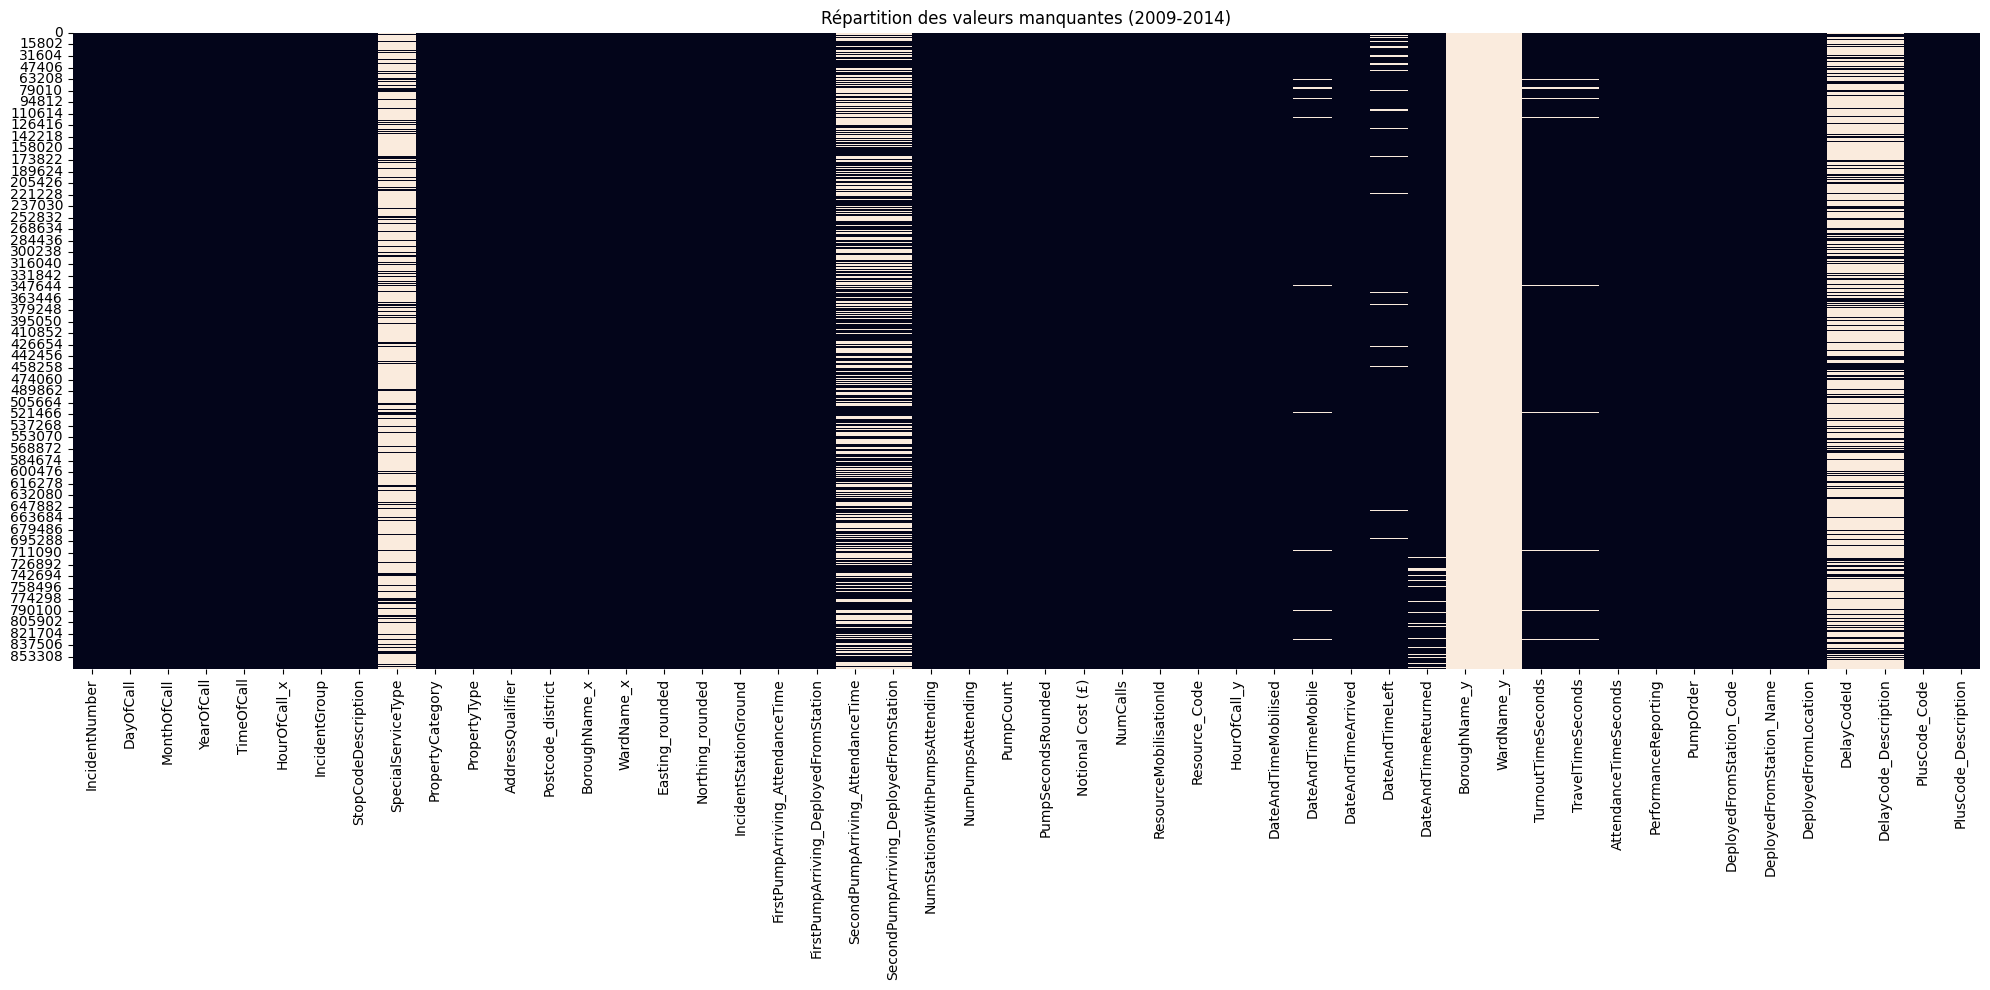

In [ ]:
periods = {
    "2009-2014": df[(df['YearOfCall'] >= 2009) & (df['YearOfCall'] <= 2014)],
    "2015-2020": df[(df['YearOfCall'] >= 2015) & (df['YearOfCall'] <= 2020)],
    "2021-2026": df[(df['YearOfCall'] >= 2021) & (df['YearOfCall'] <= 2026)]
}

for period, data in periods.items():
    plt.figure(figsize=(20,10))
    sns.heatmap(data.isna(), cbar=False)

    plt.title(f"Répartition des valeurs manquantes ({period})")
    plt.tight_layout()
    plt.show()

##Analyse visuelle des variables du dataset

###Analyses graphiques séquentielles des variables

####Distributions fréquentielles des variables Numériques

In [ ]:
selection_num = ['DayOfCall', 'MonthOfCall', 'YearOfCall', 'HourOfCall_x', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime', 'TurnoutTimeSeconds', 'TravelTimeSeconds', 'AttendanceTimeSeconds']

plt.figure(figsize=(15, 12),constrained_layout=True)
for i, col in enumerate(selection_num):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, alpha=0.4)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    print(f"graph {i} validé")
plt.show()

####Distributions statistiques des variables Numériques

In [ ]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(selection_num):
    ax = plt.subplot(2, 5, i + 1)
    sns.boxplot(y=df[col], showfliers=True, color = 'lightblue')

    # Quartiles
    q1, med, q3 = df[col].quantile([0.25, 0.5, 0.75])

    # Ajouter la "légende" avec les valeurs
    legend_text = f"Q1: {q1:.0f}\nMed: {med:.0f}\nQ3: {q3:.0f}"
    ax.text(0.70, 0.89, legend_text, transform=ax.transAxes, fontsize= 8, va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
    plt.title(col, fontsize = 8)
    plt.xlabel("")
    plt.ylabel("")

    print(f"graph {i} validé")

plt.show()

####Top 10 des catégories les plus fréquentes

In [ ]:
cols = ['IncidentStationGround','FirstPumpArriving_DeployedFromStation','SecondPumpArriving_DeployedFromStation',
        'DeployedFromStation_Name', 'WardName_x','StopCodeDescription','SpecialServiceType', 'PropertyType','Resource_Code','DelayCode_Description','PlusCode_Description']

plt.figure(figsize=(16,18), constrained_layout=True)
for i, col in enumerate(cols):
    top_values = df[col].value_counts().head(10)
    plt.subplot(4,3,i+1)
    sns.barplot(x=top_values, y=top_values.index)
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.xticks(rotation=90)
    print(f"graph {i} validé")
plt.show()

####Distribution des variables qualitatives

In [ ]:
#visualisation de la distribution des colonnes qualitatives
selection_qual = ['IncidentGroup', 'SpecialServiceType', 'PropertyCategory','BoroughName_x', 'PerformanceReporting', 'DeployedFromLocation',]

plt.figure(figsize=(14, 15), constrained_layout=True)
for i, col in enumerate(selection_qual):
    plt.subplot(4, 2, i + 1)
    sns.countplot(x=df[col], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.xticks(rotation=90)
    print(f"graph {i} validé")
plt.show()

###Analyse spatiale

####Temps d'intervention dans l'espace urbain


In [ ]:
periods = {
    "2009-2014": df[(df['YearOfCall'] >= 2009) & (df['YearOfCall'] <= 2014)],
    "2015-2020": df[(df['YearOfCall'] >= 2015) & (df['YearOfCall'] <= 2020)],
    "2021-2026": df[(df['YearOfCall'] >= 2021) & (df['YearOfCall'] <= 2026)]
}

plt.figure(figsize=(12, 18))
for i, (period, data) in enumerate(periods.items()):
    plt.subplot(3, 1, i + 1)
    plt.scatter( data["Easting_rounded"], data["Northing_rounded"], c=data["AttendanceTimeSeconds"], s=data["AttendanceTimeSeconds"]/20, cmap="YlOrRd", alpha=0.4)
    plt.colorbar(label="Temps d'intervention (s)")
    plt.title(f"Temps d'intervention dans l'espace urbain ({period})")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

La couverture spatiale est très homogène sur les trois périodes : les interventions sont réparties sur l'ensemble du territoire, sans zones vides. Cela reflète la densité d'une grande métropole où les incidents surviennent partout.
<br>
<br>
Évolution par période

* 2009-2014 : les temps d'intervention sont globalement rapides (majorité
jaune/orange). Quelques points rouges apparaissent en périphérie, probablement liés à des distances plus longues ou à un trafic plus complexe. Le centre reste bien couvert.
* 2015-2020 : la structure reste très similaire, mais on note une légère augmentation des points rouges à l'est, au sud et en périphérie. Cela pourrait s'expliquer par la croissance urbaine, l'augmentation du trafic ou des réorganisations dans le déploiement des casernes.
* 2021-2026 : la distribution ressemble aux périodes précédentes. Les couleurs dominantes restent jaune et orange, avec quelques points rouges isolés en périphérie. Aucune dégradation significative n'est observable.

####TOP 10 Casernes sollicités

In [ ]:
# Nombre d'appels par caserne (top 10 max et top 10 min)
top10max = df['IncidentStationGround'].value_counts().head(10)
top10min = df['IncidentStationGround'].value_counts().tail(10)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18,8), sharey=True)
sns.barplot(x=top10max.index, y = top10max, order = top10max.index, ax =ax1)

sns.barplot(x=top10min.index, y = top10min, order = top10min.index, ax = ax2)

ax1.set_xticks(range(len(top10max.index)))
ax1.set_xticklabels(top10max.index, rotation=90, ha='right')

ax2.set_xticks(range(len(top10min.index)))
ax2.set_xticklabels(top10min.index, rotation=90, ha='right')

ax1.title.set_text("Top 10 Max des casernes ayant le plus d'interventions")
ax2.title.set_text("Top 10 Min des casernes ayant le moins d'interventions");
plt.show();

###Analyse Temporelle

####Nombre d'incidents par années

In [ ]:
plt.figure(figsize = (15,8))
sns.countplot(x=df['YearOfCall'])
plt.title("Nombre d'interventions par an")
plt.tight_layout()
plt.show()

####Nombre d'incidents par jour


In [ ]:
plt.figure(figsize = (15,8))
sns.countplot(x=df['HourOfCall_x'])
plt.title("Nombre d'interventions par jour")
plt.tight_layout()
plt.show()

###Analyse Catégorielle

#### Catégorie d'inciendents par années

In [ ]:
plt.figure(figsize=(14,8))
sns.countplot(x=df['YearOfCall'], hue = df['IncidentGroup'])
plt.title("Nombre d'incidents par catégorie, par année")
plt.xlabel('Année')
plt.ylabel("Nombre d'incidents")

###Analyse Performance

####Classement des boroughs selon le temps moyen d’intervention

In [ ]:
# ordre des boroughs selon le temps moyen
borough_order = df.groupby('BoroughName_x')['AttendanceTimeSeconds'].mean().sort_values(ascending=False).index

plt.figure(figsize=(15,8))
sns.boxplot(x='BoroughName_x', y='AttendanceTimeSeconds', data=df, order=borough_order)
plt.title("Distribution des temps d'intervention par borough")
plt.xlabel("Borough")
plt.ylabel("Temps d'intervention (secondes)")
plt.xticks(rotation=90)
plt.show()

####Classement des camions et impact sur les temps d’arrivée

In [ ]:
# Distribution des temps d’arrivée selon le classement des camions
df.boxplot(column='AttendanceTimeSeconds', by='PumpOrder', figsize=(12,6))
plt.title("Temps d'arrivée sur site en fonction du classement du camion");

# Etape 3 : Nettoyage des données

## Traitement des valeurs manquantes

Le traitement des valeurs manquantes se fera en fonction de la nature de la variable, de son taux de NaN, et de sa distribution ou répartition.

In [ ]:
# Taux de valeurs manquantes après mise en forme des variables
(df.isna().mean() * 100).sort_values(ascending=False)

Stratégie de traitement des valeurs manquantes :

* 8 variables ont un taux de NaN significatif, supérieur à 40% : elles seront
traitées au cas par cas.

* 13 variables ont un taux de NaN faible, inférieur à 2% : les NaN seront remplacées par la médiane pour les variables quantitatives et par le mode pour les variables catégorielles. Attention cependant à prendre en compte la dimension métier pour éviter toute incohérence, notament pour certaines variables catégorielles.

* Le reste des variables ne présente aucune valeur manquante et ne nécessite, à ce stade, aucun traitement.

In [ ]:
# Afin de conserver le jeu de données initiale avant nettoyage, je créé df_c, une copie de df sur laquelle je réalise les opérations de traitement des NaN
df_c = df.copy()
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2673838 entries, 0 to 2679091
Data columns (total 50 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   IncidentNumber                          object 
 1   DayOfCall                               Int64  
 2   MonthOfCall                             Int64  
 3   YearOfCall                              Int64  
 4   TimeOfCall                              object 
 5   HourOfCall_x                            int64  
 6   IncidentGroup                           object 
 7   StopCodeDescription                     object 
 8   SpecialServiceType                      object 
 9   PropertyCategory                        object 
 10  PropertyType                            object 
 11  AddressQualifier                        object 
 12  Postcode_district                       object 
 13  BoroughName_x                           object 
 14  WardName_x                             

### Traitement des NaN pour les variables à faible taux

#### Cas des variables quantitatives : remplacement des NaN par la médiane

In [ ]:
# Identification des variables quantitatives concernées

# sélection seulement des variables numériques
quant_cols = df_c.select_dtypes(include=["int64", "float64"]).columns

# calcul du taux de NaN
na_rate = df_c[quant_cols].isna().mean() * 100

# filtre entre 0 et 2 %
quant_low_na = na_rate[(na_rate > 0) & (na_rate < 2)]

quant_low_na

,0
FirstPumpArriving_AttendanceTime,0.000337
NumCalls,0.048357
TurnoutTimeSeconds,1.047820
TravelTimeSeconds,1.051747


In [ ]:
# Tendances avant imputation
quant_low_na_vars = quant_low_na.index.tolist()
describe_table = df[quant_low_na_vars].describe().T
describe_table["NaN_%"] = df[quant_low_na_vars].isna().mean() * 100

describe_table

,count,mean,std,min,25%,50%,75%,max,NaN_%
FirstPumpArriving_AttendanceTime,2673829.0,311.646237,129.943841,1.0,229.0,292.0,369.0,1200.0,0.000337
NumCalls,2672545.0,1.365101,1.832231,1.0,1.0,1.0,1.0,369.0,0.048357
TurnoutTimeSeconds,2645821.0,78.598255,43.862704,0.0,54.0,73.0,95.0,1192.0,1.047820
TravelTimeSeconds,2645716.0,276.415553,150.901561,0.0,175.0,250.0,346.0,1198.0,1.051747


In [ ]:
# Imputation par la médiane
for col in quant_low_na_vars:
    df_c[col].fillna(df_c[col].median(), inplace=True)

/tmp/ipykernel_17481/3767393909.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_c[col].fillna(df_c[col].median(), inplace=True)


In [ ]:
# Tendances après imputation
describe_table_c = df_c[quant_low_na_vars].describe().T
describe_table_c["NaN_%"] = df_c[quant_low_na_vars].isna().mean() * 100

describe_table_c

,count,mean,std,min,25%,50%,75%,max,NaN_%
FirstPumpArriving_AttendanceTime,2673838.0,311.646171,129.943627,1.0,229.0,292.0,369.0,1200.0,0.0
NumCalls,2673838.0,1.364925,1.831805,1.0,1.0,1.0,1.0,369.0,0.0
TurnoutTimeSeconds,2673838.0,78.539596,43.636021,0.0,54.0,73.0,95.0,1192.0,0.0
TravelTimeSeconds,2673838.0,276.137728,150.130099,0.0,176.0,250.0,345.0,1198.0,0.0


Absence de NaN, ce qui confirme la réussite de l'imputation.
Par ailleurs les modifications statistiques observées sont mineures : imputation validée, à confirmer par l'analyse graphique des distributions.

Pour évaluer le type de traitement je décide de tester l'inputation par la moyenne, même si au vu de l'allure des données la médiane est plus appropriée.

In [ ]:
df_cmean = df[quant_low_na_vars]
df_cmean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2673838 entries, 0 to 2679091
Data columns (total 4 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   FirstPumpArriving_AttendanceTime  float64
 1   NumCalls                          float64
 2   TurnoutTimeSeconds                float64
 3   TravelTimeSeconds                 float64
dtypes: float64(4)
memory usage: 102.0 MB


In [ ]:
# Imputation par la moyenne
for col in quant_low_na_vars:
    df_cmean[col].fillna(df_cmean[col].mean(), inplace=True)

/tmp/ipykernel_17481/2214271802.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cmean[col].fillna(df_cmean[col].mean(), inplace=True)
/tmp/ipykernel_17481/2214271802.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cmean[col].fillna(df_cmean[col].mean(), inplace=True)


In [ ]:
# Tendances après imputation par la moyenne
describe_table_cmean = df_cmean[quant_low_na_vars].describe().T
describe_table_cmean["NaN_%"] = df_cmean[quant_low_na_vars].isna().mean() * 100

describe_table_cmean

,count,mean,std,min,25%,50%,75%,max,NaN_%
FirstPumpArriving_AttendanceTime,2673838.0,311.646237,129.943622,1.0,229.0,292.0,369.0,1200.0,0.0
NumCalls,2673838.0,1.365101,1.831788,1.0,1.0,1.0,1.0,369.0,0.0
TurnoutTimeSeconds,2673838.0,78.598255,43.632298,0.0,54.0,73.0,95.0,1192.0,0.0
TravelTimeSeconds,2673838.0,276.415553,150.105912,0.0,176.0,252.0,345.0,1198.0,0.0


On note aucune différence entre l'imputation entre médiane et moyenne, ce qui semble logique au vu des faibles taux de NaN. A confirmer par une analyse graphique.

#### Cas des variables qualitatives : remplacement des NaN par le mode, hors cas particulier

In [ ]:
# Identification des variables qualitatives concernées

# sélection seulement des variables catégorielles
qual_cols = df_c.select_dtypes(include=["object", "category"]).columns

# calcul du taux de NaN
na_rate_qual = df_c[qual_cols].isna().mean() * 100

# filtre entre 0 et 2 %
qual_low_na = na_rate_qual[(na_rate_qual > 0) & (na_rate_qual < 2)]

qual_low_na

,0
IncidentGroup,0.000150
WardName_x,0.037998
IncidentStationGround,0.000112
FirstPumpArriving_DeployedFromStation,0.001346
DateAndTimeMobile,1.042808
DateAndTimeLeft,1.398551
DeployedFromStation_Code,0.000898
DeployedFromStation_Name,0.000898
DeployedFromLocation,0.063242


Attention pour certaines variables, il n'est pas possible de remplacer les NaN par le mode. Il s'agit de :

*   DateAndTimeMobile et DateAndTimeLeft qui sont des variables temporelles. Les remplacer par le mode créera du non sens. Au vu du faible taux de NaN et de la taille du jeux de données, supprimer les lignes concernées est acceptable.

*   DeployedFromLocation, qui correspond à la localisation du véhicule au moment du départ. dans ce cas la présence de NaN peut avoir un vrai sens : le camion était déjà mobilisé ailleurs, ou il est en déplacement et la localisation n'est pas enregistrée. Pour cette variable je décide de remplacer les NaN par "Unknown".

In [ ]:
# Tendances avant imputation
qual_low_na_vars = qual_low_na.index.tolist()

for col in qual_low_na_vars:

    print("\n" + "="*70)
    print(f"Distribution de la variable : {col}")
    print("="*70)

    # remplacement temporaire des NaN pour les afficher
    temp = df[col].fillna("NaN")

    # calcul des distributions
    counts = temp.value_counts().head(10)
    percentages = temp.value_counts(normalize=True).head(10) * 100

    # taux global de NaN
    na_rate = df[col].isna().mean() * 100

    # création du tableau
    summary = pd.DataFrame({
        "Category": counts.index,
        "Count": counts.values,
        "Percentage (%)": percentages.values,
        "NaN_rate (%)": na_rate
    })

    display(summary)



Distribution de la variable : IncidentGroup


,Category,Count,Percentage (%),NaN_rate (%)
0,False Alarm,1562252,58.427324,0.00015
1,Special Service,598501,22.383592,0.00015
2,Fire,513081,19.188934,0.00015
3,NaN,4,0.000150,0.00015



Distribution de la variable : WardName_x


,Category,Count,Percentage (%),NaN_rate (%)
0,West End,31664,1.184215,0.037998
1,St. James's,23775,0.889171,0.037998
2,Heathrow Villages,14669,0.548612,0.037998
3,Bloomsbury,14218,0.531745,0.037998
4,Holborn & Covent Garden,13784,0.515514,0.037998
5,Regent's Park,12402,0.463828,0.037998
6,Whitechapel,9917,0.370890,0.037998
7,WEST END,9570,0.357912,0.037998
8,Kilburn,9396,0.351405,0.037998
9,Marylebone,9337,0.349198,0.037998



Distribution de la variable : IncidentStationGround


...

,Category,Count,Percentage (%),NaN_rate (%)
0,A24,84711,3.168143,0.000898
1,A21,61330,2.293707,0.000898
2,H22,52478,1.962647,0.000898
3,G36,50935,1.904940,0.000898
4,G27,49733,1.859986,0.000898
5,A23,48073,1.797902,0.000898
6,A43,46740,1.748049,0.000898
7,A41,46188,1.727405,0.000898
8,H24,44458,1.662704,0.000898
9,A33,43292,1.619096,0.000898



Distribution de la variable : DeployedFromStation_Name


,Category,Count,Percentage (%),NaN_rate (%)
0,Soho,84711,3.168143,0.000898
1,Paddington,61330,2.293707,0.000898
2,Lambeth,52478,1.962647,0.000898
3,Hammersmith,50935,1.904940,0.000898
4,North Kensington,49733,1.859986,0.000898
5,Euston,48073,1.797902,0.000898
6,Kentish Town,46740,1.748049,0.000898
7,West Hampstead,46188,1.727405,0.000898
8,Brixton,44458,1.662704,0.000898
9,Tottenham,43292,1.619096,0.000898



Distribution de la variable : DeployedFromLocation


,Category,Count,Percentage (%),NaN_rate (%)
0,Home Station,2581356,96.541227,0.063242
1,Other Station,90791,3.395531,0.063242
2,NaN,1691,0.063242,0.063242


In [ ]:
# Traitement des variables catégorielles hors cas particuliers : remplacer les NaN par le mode

mode_vars = [
    "IncidentGroup",
    "WardName_x",
    "IncidentStationGround",
    "FirstPumpArriving_DeployedFromStation",
    "DeployedFromStation_Code",
    "DeployedFromStation_Name"
]

for col in mode_vars:
    df_c[col].fillna(df_c[col].mode()[0], inplace=True)

/tmp/ipykernel_17481/238452282.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_c[col].fillna(df_c[col].mode()[0], inplace=True)


In [ ]:
df_c[mode_vars].isna().sum()

,0
IncidentGroup,0
WardName_x,0
IncidentStationGround,0
FirstPumpArriving_DeployedFromStation,0
DeployedFromStation_Code,0
DeployedFromStation_Name,0


Plus de NaN : l'imputation par le mode a fonctionné.

In [ ]:
# Tendances après imputation par le mode

for col in mode_vars:

    print("\n" + "="*70)
    print(f"Distribution de la variable : {col}")
    print("="*70)

    # remplacement temporaire des NaN pour les afficher
    temp = df_c[col].fillna("NaN")

    # calcul des distributions
    counts = temp.value_counts().head(10)
    percentages = temp.value_counts(normalize=True).head(10) * 100

    # taux global de NaN
    na_rate = df_c[col].isna().mean() * 100

    # création du tableau
    summary = pd.DataFrame({
        "Category": counts.index,
        "Count": counts.values,
        "Percentage (%)": percentages.values,
        "NaN_rate (%)": na_rate
    })

    display(summary)


L'imputation par le mode ne modifie pas de façon significative les statistiques de répartition : imputation validée.

In [ ]:
# Taitement des cas particuliers : DateAndTimeMobile et DateAndTimeLeft (suppression des lignes)

print("Nombre de lignes avec NaN avant suppression :","\n", df_c[["DateAndTimeMobile", "DateAndTimeLeft"]].isna().sum())
print("Dimension avant suppression :", df_c.shape)
print("\n")

# "Suppression des lignes concernées"
df_c = df_c.dropna(subset=["DateAndTimeMobile", "DateAndTimeLeft"])

print("Nombre de lignes avec NaN après suppression :","\n", df_c[["DateAndTimeMobile", "DateAndTimeLeft"]].isna().sum())
print("Dimension après suppression :", df_c.shape)

Nombre de lignes avec NaN avant suppression : 
 DateAndTimeMobile    27883
DateAndTimeLeft      37395
dtype: int64
Dimension avant suppression : (2673838, 50)


Nombre de lignes avec NaN après suppression : 
 DateAndTimeMobile    0
DateAndTimeLeft      0
dtype: int64
Dimension après suppression : (2611983, 50)


La suppression des lignes concernées a bien était exécutée.

In [ ]:
# Tendances pour observer l'effet de la suppression de ligne sur les variables

for col in qual_low_na_vars:

    print("\n" + "="*70)
    print(f"Distribution de la variable : {col}")
    print("="*70)

    # remplacement temporaire des NaN pour les afficher
    temp = df_c[col].fillna("NaN")

    # calcul des distributions
    counts = temp.value_counts().head(10)
    percentages = temp.value_counts(normalize=True).head(10) * 100

    # taux global de NaN
    na_rate = df_c[col].isna().mean() * 100

    # création du tableau
    summary = pd.DataFrame({
        "Category": counts.index,
        "Count": counts.values,
        "Percentage (%)": percentages.values,
        "NaN_rate (%)": na_rate
    })

    display(summary)


Pas d'impact significatif de la suppression des lignes sur les statistiques de répartition des variables : modification validée.

In [ ]:
# Imputation du cas particulier DeployedFromLocation : remplacer les NaN par "Unknown"

df_c["DeployedFromLocation"] = df_c["DeployedFromLocation"].fillna("Unknown")

In [ ]:
# Tendances après imputation pour "DeployedFromLocation"

col = "DeployedFromLocation"

print("\n" + "="*70)
print(f"Distribution de la variable : {col}")
print("="*70)

# remplacement temporaire des NaN pour les afficher
temp = df_c[col].fillna("NaN")

# calcul des distributions
counts = temp.value_counts().head(10)
percentages = temp.value_counts(normalize=True).head(10) * 100

# taux global de NaN
na_rate = df_c[col].isna().mean() * 100

# création du tableau
summary = pd.DataFrame({
    "Category": counts.index,
    "Count": counts.values,
    "Percentage (%)": percentages.values,
    "NaN_rate (%)": na_rate
})

display(summary)

Pas de NaN et apparition de la catégorie Unknown : imputation validée.

Avant de passer aux traitements des variables à taux élevé de NaN, il convient de vérifier l'impact des suppressions de lignes sur les variables quantitatives à faible taux de NaN imputées par la médiane.

In [ ]:
# Tendances après imputation par la médiane et suppression de lignes du jeu de données
describe_table_c = df_c[quant_low_na_vars].describe().T
describe_table_c["NaN_%"] = df_c[quant_low_na_vars].isna().mean() * 100

describe_table_c

,count,mean,std,min,25%,50%,75%,max,NaN_%
FirstPumpArriving_AttendanceTime,2611983.0,312.787823,128.549214,1.0,230.0,293.0,370.0,1200.0,0.0
NumCalls,2611983.0,1.365300,1.837303,1.0,1.0,1.0,1.0,369.0,0.0
TurnoutTimeSeconds,2611983.0,78.190919,43.454961,0.0,54.0,73.0,95.0,1192.0,0.0
TravelTimeSeconds,2611983.0,276.896084,150.776857,0.0,176.0,251.0,346.0,1198.0,0.0


Pas d'impact de la suppression de lignes.

### Traitement des NaN pour les variables à fort taux

In [ ]:
# Vérification des nouveaux taux de NaN suite à la suppression de lignes
(df_c.isna().mean() * 100).sort_values(ascending=False)

la suppression des lignes de la première phase du traitement des NaN a légèrement impacté les forts taux de NA, sans effet sur leur interprétation.

#### Cas des variables quantitatives

In [ ]:
# sélection des variables quantitatives qui contiennent encore des NaN
quant_cols = df_c.select_dtypes(include=["int64", "float64"]).columns
quant_with_na = df_c[quant_cols].columns[df_c[quant_cols].isna().any()]

quant_with_na

Index(['SecondPumpArriving_AttendanceTime'], dtype='object')

In [ ]:
na_rates = df_c[quant_with_na].isna().mean() * 100

na_rates.sort_values(ascending=False)

1 variable concernée
- SecondPumpArriving_AttendanceTime : le temps de réponse du second véhicule mobilisé. Dans ce cas, on supposera, en cohérence avec le contexte métier, que les NaN correspondent à l'absence de 2ème camion sur l'intervention. C'est une variable numérique, les NaN sont donc conservés, et une variable indicatrice de type booléen est créé ("SecondPumpMobilised") pour signiifer si un second camion est mobilisé ou pas.

In [ ]:
# création de la variable indicatrice "SecondPumpMobilised"
df_c["SecondPumpMobilised"] = df_c["SecondPumpArriving_AttendanceTime"].notna()

In [ ]:
df_c["SecondPumpMobilised"].describe()

In [ ]:
df_c["SecondPumpMobilised"].info()

#### Cas des variables qualitatives

In [ ]:
# sélectionner les variables qualitatives qui contiennent encore des NaN
qual_cols = df_c.select_dtypes(include=["object", "category"]).columns
qual_with_na = df_c[qual_cols].columns[df_c[qual_cols].isna().any()]

qual_with_na

Index(['SpecialServiceType', 'SecondPumpArriving_DeployedFromStation',
       'DateAndTimeReturned', 'BoroughName_y', 'WardName_y', 'DelayCodeId',
       'DelayCode_Description'],
      dtype='object')

In [ ]:
na_rates_qual = df_c[qual_with_na].isna().mean() * 100

na_rates_qual.sort_values(ascending=False)

7 variables sont concernées, à traiter au cas par cas. A noter qu'il n'est pas possible de traiter DateAndTimeReturned car c'est une variable de temps, et que le remplacement des NaN entraînera de la fausse information. Compte tenu du fort taux de NaN la suppression de ligne aurait un impact trop important sur le jeu de données.
Il faut s'interroger sur la pertinenence de cette variable.

In [ ]:
# Tendances avant imputation

for col in qual_with_na:

    print("\n" + "="*70)
    print(f"Distribution de la variable : {col}")
    print("="*70)

    # remplacement temporaire des NaN pour les afficher
    temp = df_c[col].fillna("NaN")

    # calcul des distributions
    counts = temp.value_counts().head(10)
    percentages = temp.value_counts(normalize=True).head(10) * 100

    # taux global de NaN
    na_rate = df_c[col].isna().mean() * 100

    # création du tableau
    summary = pd.DataFrame({
        "Category": counts.index,
        "Count": counts.values,
        "Percentage (%)": percentages.values,
        "NaN_rate (%)": na_rate
    })

    display(summary)


##### SpecialServiceType

SpecialServiceType est une sous catégorie de Special Service. Un NaN peut donc apparaître lorsque l'incident est Fire ou False Alarm. Dans ce cas Les NaN seront remplacés par NotApplicable.

In [ ]:
# Vérification de la correspondance des NaN avec les catégories d'Incidentgroup
df_c[df_c["SpecialServiceType"].isna()]["IncidentGroup"].value_counts()

,count
IncidentGroup,
False Alarm,1535928
Fire,499802
Special Service,15


15 incidents présentent de vraies valeurs manquantes. au vu du faible nombre de ligne et de la taille du jeu de données, il est préférable de les supprimer plutôt que de créer de la fausse information sur une variable métier.

In [ ]:
# imputation des NaN pour la variable "SpecialServiceType" :

# Supression des 15 lignes de vraies valeurs manquantes
df_c["SpecialServiceType"] = df_c["SpecialServiceType"].fillna("NotApplicable")

# imputation des autres NaN par "NotApplicable"
df_c["SpecialServiceType"] = df_c["SpecialServiceType"].fillna("NotApplicable")

##### SecondPumpArriving_DeployedFromStation

SecondPumpArriving_DeployedFromStation correspond à la station d'origine du second camion. Comme nous l'avons vu plus haut avec la variable "SecondPumpArriving_AttendanceTime", les NaN peuvent s'expliquer par l'bsence d'envoi d'un 2ème camion.

In [ ]:
# Vérification de la correspondance des NaN avec SecondPumpArriving_AttendanceTime
pd.crosstab(
    df_c["SecondPumpArriving_AttendanceTime"].isna(),
    df_c["SecondPumpArriving_DeployedFromStation"].isna(),
    margins=True
)

SecondPumpArriving_DeployedFromStation,False,True,All
SecondPumpArriving_AttendanceTime,,,
False,1571711,17,1571728
True,0,1040255,1040255
All,1571711,1040272,2611983


Seulement 17 incidents sont incohérents : on a le temps d'arrivé du second camion, mais pas sa station de départ. Pour ces lignes les NaN seront remplacés par "UnknownStation". Pour les autres NaN, on les remplace par "NoSecondPump".

In [ ]:
# Imputation de la variable SecondPumpArriving_DeployedFromStation

df_c.loc[
    df_c["SecondPumpArriving_DeployedFromStation"].isna() &
    df_c["SecondPumpArriving_AttendanceTime"].notna(),
    "SecondPumpArriving_DeployedFromStation"
] = "UnknownStation"

df_c["SecondPumpArriving_DeployedFromStation"] = df_c[
    "SecondPumpArriving_DeployedFromStation"
].fillna("NoSecondPump")

##### BoroughName_y et WardName_y

Ces 2 variables sont issues des jeux de données Mobilisation et correspondent  aux Boroughs et aux Wards d'origine des camions, à distinguer de BoroughName_x et WardName_x qui eux consernent la caserne. Ils peuvent être différents.

In [ ]:
print(
    (
        df_c[["BoroughName_x", "BoroughName_y"]]
        .dropna()
        .eval("BoroughName_x == BoroughName_y")
        .mean()
    )
)

In [ ]:
print(
    (
        df_c[["WardName_x", "WardName_y"]]
        .dropna()
        .eval("WardName_x == WardName_y")
        .mean()
    )
)

Forte correspondance pour les Boroughs (99%), par contre très faible correspondance pour les Wards (6%). Ce décalage semble incohérent car les Wards sont liés aux Borough. A explorer lors du traitement des outliers. Ce sont des variables géographiques qui peuvent avoir un sens métier. Il est donc préférable de ne pas remplacer les NaN de BoroughName_y et WardName_y pour l'instant.

##### DelayCodeId et DelayCode_Description

Il s'agit du code qui explique un retard éventuel et la description associée. On supposera que les NaN correspondent à une absence de retard.

In [ ]:
# Imputation des NaN pour les variables DelayCodeId et DelayCode_Description par "NoDelay"

df_c["DelayCodeId"] = df_c["DelayCodeId"].fillna("NoDelay")
df_c["DelayCode_Description"] = df_c["DelayCode_Description"].fillna("NoDelay")

In [ ]:
# Tendances avant imputation

for col in qual_with_na:

    print("\n" + "="*70)
    print(f"Distribution de la variable : {col}")
    print("="*70)

    # remplacement temporaire des NaN pour les afficher
    temp = df_c[col].fillna("NaN")

    # calcul des distributions
    counts = temp.value_counts().head(10)
    percentages = temp.value_counts(normalize=True).head(10) * 100

    # taux global de NaN
    na_rate = df_c[col].isna().mean() * 100

    # création du tableau
    summary = pd.DataFrame({
        "Category": counts.index,
        "Count": counts.values,
        "Percentage (%)": percentages.values,
        "NaN_rate (%)": na_rate
    })

    display(summary)


Toutes les variables n'ont pas pu être modifiées pour des raisons de sens et de cohérence métier. Celles qui l'ont été se sont vu appliquer des catégories de remplacement, en fonction du sens métier de la variable.

### Bilan du traitement des valeurs manquantes

In [ ]:
(df_c.isna().mean() * 100).sort_values(ascending=False)

A l'issue de cette étape de nettoyage des valeurs manquantes, seules 4 variables en présentent encore car les remplacer étaient un non-sens, ou la suppression des lignes impactait trop le jeu de données. Ces variables devront être remises dans leur contexte pour toute exploitation ultérieure, voir analysée sur un jeu de données tronqué.
Pour celles qui ont subit un traitement, je n’observe aucun impact significatif sur le comportement des données.

## Traitement des valeurs extrêmes

In [ ]:
# Création du dataframe df_c1, à partir du df_c, pour le traitement des valeurs extrêmes
df_c1 = df_c.copy()

### Traitement des variables quantitatives

In [ ]:
quant_cols = df_c1.select_dtypes(include=["int64", "float64"]).columns

quant_cols

Index(['DayOfCall', 'MonthOfCall', 'YearOfCall', 'HourOfCall_x',
       'Easting_rounded', 'Northing_rounded',
       'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime',
       'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount',
       'PumpSecondsRounded', 'Notional Cost (£)', 'NumCalls', 'HourOfCall_y',
       'TurnoutTimeSeconds', 'TravelTimeSeconds', 'AttendanceTimeSeconds',
       'PumpOrder'],
      dtype='object')

In [ ]:
print(len(quant_cols), "variables sont concernées.")

#### Recherche de valeurs impossibles

In [ ]:
# Valeurs négatives
(df_c1[quant_cols] < 0).sum()

Aucune valeur négative.

In [ ]:
# Cohérence des variables temporelles (valeurs possibles)

df_c1[(df_c1["DayOfCall"] < 1) | (df_c1["DayOfCall"] > 31)]

df_c1[(df_c1["MonthOfCall"] < 1) | (df_c1["MonthOfCall"] > 12)]

df_c1[(df_c1["HourOfCall_x"] < 0) | (df_c1["HourOfCall_x"] > 23)]

Aucune incohérence sur les variables de temps

In [ ]:
# Cohérence des coordonnées
(df_c1[["Easting_rounded","Northing_rounded"]] <= 0).sum()

Coordonnées cohérentes avec Londres car aucune valeurs négatives ou égale à 0

In [ ]:
# Cohérence entre les variables de temps
mask_incoherent = (
    df_c1["AttendanceTimeSeconds"] !=
    (df_c1["TurnoutTimeSeconds"] + df_c1["TravelTimeSeconds"])
)

mask_incoherent.sum()

In [ ]:
mask_incoherent.mean()

Très faible taux d'incohérence sur les variables de temps.

In [ ]:
# Cohérence des variables de comptage
count_vars = ["NumStationsWithPumpsAttending",
"NumPumpsAttending",
"PumpCount",
"NumCalls",
"PumpOrder"]

(df_c1[count_vars] < 1).sum()

Cohérence des comptages car aucune valeur n'est inférieure à 1

#### Traitement des valeurs extrêmes

##### Analyse des boxplots

In [ ]:
for col in quant_cols:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_c1[col])

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

Seules les variables de temps ne présentent pas de valeurs extrêmes. Elle ne feront donc pas l'objet d'un traitement des valeurs extrêmes.

##### Cas des variables géographiques

'Easting_rounded' et 'Northing_rounded' présentent des valeurs extrêmes. Il faut vérifier si ce sont des valeurs possibles, en sachant que les bornes des coordonnées  du grand Londres sont :
- 490000 - 570000 pour Easting_rounded
- 150000 – 210000 pour Northing_rounded

In [ ]:
df_c1["Northing_rounded"].describe()
df_c1["Easting_rounded"].describe()

In [ ]:
df_c1.nlargest(10, "Northing_rounded")
df_c1.nsmallest(10, "Northing_rounded")

In [ ]:
plt.scatter(
    df_c1["Easting_rounded"],
    df_c1["Northing_rounded"],
    s=1,
    alpha=0.2
)
plt.title("Distribution géographique des incidents")
plt.show()

Les coordonnées extrêmes correspondent bien à des valeurs réelles et plausibles. Ce ne sont pas des valeurs aberrantes, il faut les conserver au risque de perdre de l'information.

##### Traitement des autres variables

Il faut tout d'abord vérifier la réalité des incidents les plus extrêmes. pour celà je décide de me baser sur le nombre d'appel reçu et de m'interroger sur le top10.

In [ ]:
# sélectionner les 10 incidents avec le plus d'appels
top_incidents = (
    df_c1.groupby("IncidentNumber")
    .agg({
        "NumCalls": "max",
        "DayOfCall": "first",
        "MonthOfCall": "first",
        "YearOfCall": "first",
        "TimeOfCall": "first",
        "BoroughName_x": "first",
        "WardName_x": "first"
    })
    .sort_values("NumCalls", ascending=False)
    .head(10)
    .reset_index()
)

top_incidents

Ces évènements correspondent à des incidents majeurs réels tels que l’incendie de la Grenfell Tower.

Malgrè tout, conserver ces valeurs trés décallées, impactera l'interprétation des données dans un contexte habituel.
Je décide donc de capper (winsorisation) les valeurs maximales des variables concernées. je décide de tester à 1% et à 5%. Pour celà je cré des copies de df_c1 : df_c1_1 (cappe à 1%) et df_c1_5 (cappe à 5%)
Les valeurs minimales ne seront pas cappées car elles sojn trés nombreuses, l'impact sera faible, autant éviter la suppression de données réelles.

In [ ]:
df_c1_1 = df_c1.copy()
df_c1_5 = df_c1.copy()

In [ ]:
# Cappe à 1% en max

vars_cap_max = [
    "TurnoutTimeSeconds",
    "TravelTimeSeconds",
    "AttendanceTimeSeconds",
    "NumStationsWithPumpsAttending",
    "NumPumpsAttending",
    "PumpCount",
    "PumpSecondsRounded",
    "Notional Cost (£)",
    "NumCalls"]

for col in vars_cap_max:
    p99 = df_c1_1[col].quantile(0.99)
    df_c1_1[col] = df_c1_1[col].clip(upper=p99)

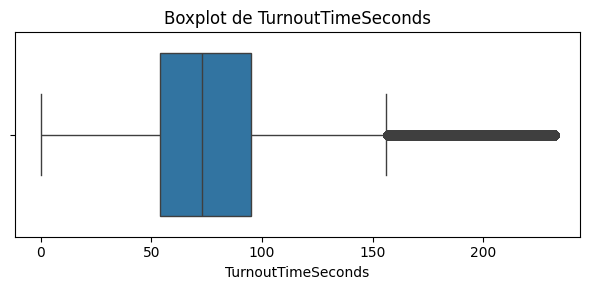

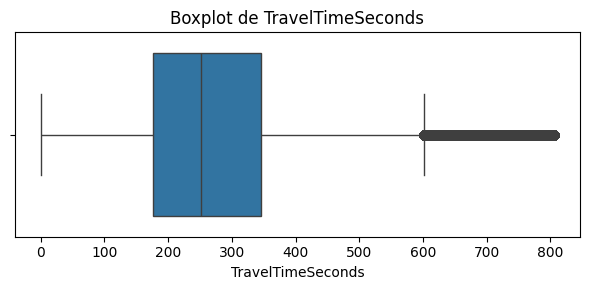

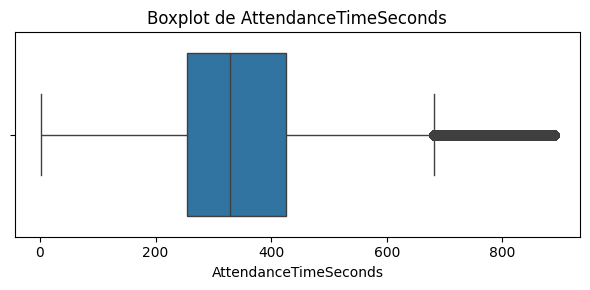

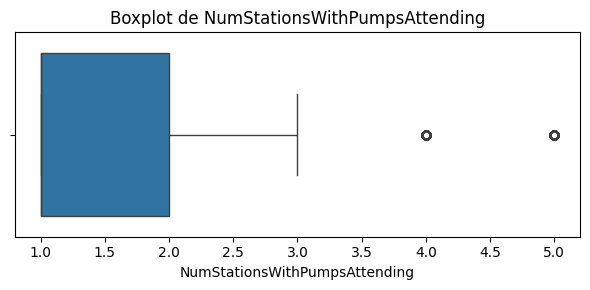

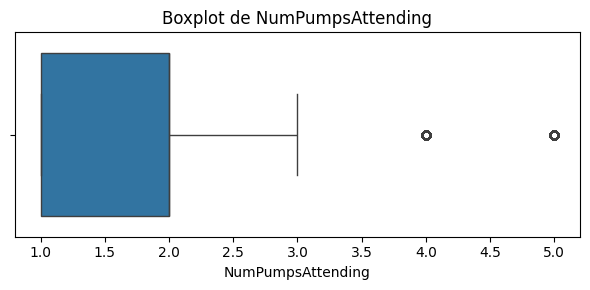

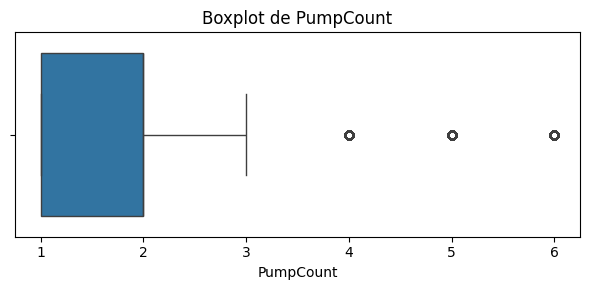

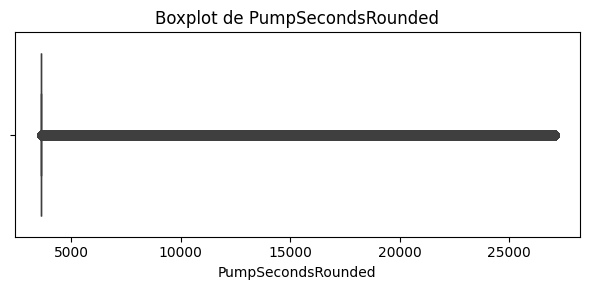

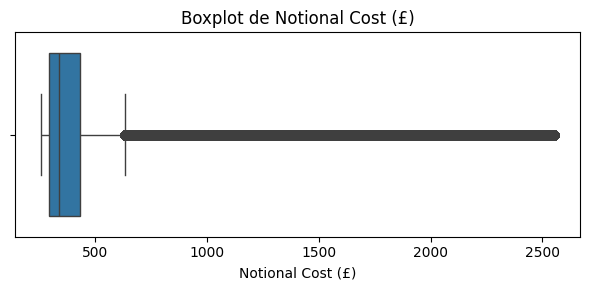

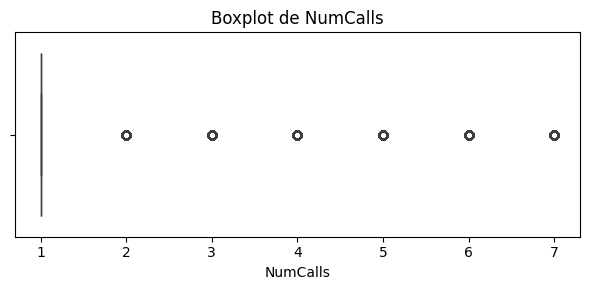

In [ ]:
for col in vars_cap_max:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_c1_1[col])

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
# Cappe à 5% en max

vars_cap_max = [
    "TurnoutTimeSeconds",
    "TravelTimeSeconds",
    "AttendanceTimeSeconds",
    "NumStationsWithPumpsAttending",
    "NumPumpsAttending",
    "PumpCount",
    "PumpSecondsRounded",
    "Notional Cost (£)",
    "NumCalls"]

for col in vars_cap_max:
    p95 = df_c1_5[col].quantile(0.95)
    df_c1_5[col] = df_c1_5[col].clip(upper=p95)

In [ ]:
for col in vars_cap_max:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_c1_5[col])

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
for col in vars_cap_max:

    fig, axes = plt.subplots(1, 3, figsize=(15,4))

    sns.boxplot(x=df_c1[col], ax=axes[0])
    axes[0].set_title(f"{col} - original")

    sns.boxplot(x=df_c1_1[col], ax=axes[1])
    axes[1].set_title(f"{col} - cap 1%")

    sns.boxplot(x=df_c1_5[col], ax=axes[2])
    axes[2].set_title(f"{col} - cap 5%")

    plt.tight_layout()
    plt.show()

Capper à 1% est déjà significatif. On voit moins de valeurs extrêmes.
A 5% on ne voit plus de valeurs extrêmes ce qui biaise trop le contexte opérationnel de ce jeu de donné. On décide de capper à 1%. la suite du traitement sera effectué sur df_c1_1

### Traitement des variables qualitatives

In [ ]:
qual_cols = df_c1_1.select_dtypes(include=["object", "category"]).columns
qual_cols

Index(['IncidentNumber', 'TimeOfCall', 'IncidentGroup', 'StopCodeDescription',
       'SpecialServiceType', 'PropertyCategory', 'PropertyType',
       'AddressQualifier', 'Postcode_district', 'BoroughName_x', 'WardName_x',
       'IncidentStationGround', 'FirstPumpArriving_DeployedFromStation',
       'SecondPumpArriving_DeployedFromStation', 'ResourceMobilisationId',
       'Resource_Code', 'DateAndTimeMobilised', 'DateAndTimeMobile',
       'DateAndTimeArrived', 'DateAndTimeLeft', 'DateAndTimeReturned',
       'BoroughName_y', 'WardName_y', 'PerformanceReporting',
       'DeployedFromStation_Code', 'DeployedFromStation_Name',
       'DeployedFromLocation', 'DelayCodeId', 'DelayCode_Description',
       'PlusCode_Code', 'PlusCode_Description'],
      dtype='object')

In [ ]:
qual_summary = pd.DataFrame({
    "Variable": qual_cols,
    "Nb_categories": [df_c1_1[col].nunique() for col in qual_cols]
})

qual_summary.sort_values("Nb_categories", ascending=False)

,Variable,Nb_categories
14,ResourceMobilisationId,2611957
19,DateAndTimeLeft,2392238
18,DateAndTimeArrived,2368008
17,DateAndTimeMobile,2295084
0,IncidentNumber,1724328
16,DateAndTimeMobilised,1677501
20,DateAndTimeReturned,863642
1,TimeOfCall,172281
10,WardName_x,1475
22,WardName_y,704


Les variables à valeur unique et celles qui concernent les dates ne sont pas concernées par ce traitement. La cohérence des valeurs temporelles à déjà était vérifié plus haut.

#### Variables < 35 catégories

In [ ]:
# j'affiche les valeurs des variables qui ont moins de 35 catégories

for col in qual_cols:
    n_cat = df_c1_1[col].nunique(dropna=True)
    if n_cat < 35:
        print("\n" + "="*60)
        print(f"Variable : {col}")
        print(f"Nombre de catégories : {n_cat}")
        print("="*60)
        print(df_c1_1[col].value_counts(dropna=False))


Variable : IncidentGroup
Nombre de catégories : 3
IncidentGroup
False Alarm        1535928
Special Service     576253
Fire                499802
Name: count, dtype: int64

Variable : StopCodeDescription
Nombre de catégories : 10
StopCodeDescription
AFA                               1167705
Special Service                    576238
False alarm - Good intent          329524
Primary Fire                       316234
Secondary Fire                     182617
False alarm - Malicious             38694
Chimney Fire                          788
Late Call                             163
Alleged Fire Risk                      13
Use of Special Operations Room          7
Name: count, dtype: int64

Variable : SpecialServiceType
Nombre de catégories : 22
SpecialServiceType
NotApplicable                      2035745
Effecting entry/exit                130392
Flooding                            109797
RTC                                  94651
No action (not false alarm)          51869
Lift Release 

je ne vois pas de données abhérantes pour ce premier groupe. mais il convient de vérifier la synthaxe.

In [ ]:
# Vérification des espaces et de la casse
for col in qual_cols:
  n_cat = df_c1_1[col].nunique(dropna=True)
  if n_cat < 35:
    cleaned = df_c1_1[col].dropna().str.strip().str.lower()
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print("Valeurs uniques originales :", df_c1_1[col].nunique())
    print("Valeurs uniques nettoyées :", cleaned.nunique())


IncidentGroup
Valeurs uniques originales : 3
Valeurs uniques nettoyées : 3

StopCodeDescription
Valeurs uniques originales : 10
Valeurs uniques nettoyées : 10

SpecialServiceType
Valeurs uniques originales : 22
Valeurs uniques nettoyées : 22

PropertyCategory
Valeurs uniques originales : 9
Valeurs uniques nettoyées : 9

AddressQualifier
Valeurs uniques originales : 11
Valeurs uniques nettoyées : 11

BoroughName_x
Valeurs uniques originales : 33
Valeurs uniques nettoyées : 33

BoroughName_y
Valeurs uniques originales : 33
Valeurs uniques nettoyées : 33

PerformanceReporting
Valeurs uniques originales : 3
Valeurs uniques nettoyées : 3

DeployedFromLocation
Valeurs uniques originales : 3
Valeurs uniques nettoyées : 3

DelayCodeId
Valeurs uniques originales : 11
Valeurs uniques nettoyées : 1

DelayCode_Description
Valeurs uniques originales : 11
Valeurs uniques nettoyées : 11

PlusCode_Code
Valeurs uniques originales : 3
Valeurs uniques nettoyées : 3

PlusCode_Description
Valeurs uniques 

Pas de problèmes de casse ou d'espaces pour les variables à moins de 35 catégories

#### Variables qui renvoie un nom de station

In [ ]:
station_vars = [
    "FirstPumpArriving_DeployedFromStation",
    "SecondPumpArriving_DeployedFromStation",
    "DeployedFromStation_Name",
    "IncidentStationGround"]

In [ ]:
# Vérification des espaces et de la casse
for col in station_vars:
    cleaned = df_c1_1[col].dropna().str.strip().str.lower()
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print("Valeurs uniques originales :", df_c1_1[col].nunique())
    print("Valeurs uniques nettoyées :", cleaned.nunique())


FirstPumpArriving_DeployedFromStation
Valeurs uniques originales : 118
Valeurs uniques nettoyées : 118

SecondPumpArriving_DeployedFromStation
Valeurs uniques originales : 117
Valeurs uniques nettoyées : 117

DeployedFromStation_Name
Valeurs uniques originales : 118
Valeurs uniques nettoyées : 118

IncidentStationGround
Valeurs uniques originales : 102
Valeurs uniques nettoyées : 102


Pas de problème de casse ou d'espace pour ces variables.

In [ ]:
# recherche de caractères inhabituels
for col in station_vars:
    mask = df_c1_1[col].str.contains(r"[^a-zA-Z\s]", na=False)
    print("\n", col)
    print(df_c1_1.loc[mask, col].unique())

Pas de caractères inhabituels

In [ ]:
# Détection des noms presque identiques

from difflib import get_close_matches
stations = sorted(df_c1_1["DeployedFromStation_Name"].dropna().unique())
for s in stations:
    matches = get_close_matches(s, stations, n=5, cutoff=0.9)
    if len(matches) > 1:
        print(matches)

In [ ]:
# Liste des stations (source LFB)

lfb_stations_reference = [
"Acton","Addington","Barking","Barnet","Battersea","Beckenham","Bethnal Green",
"Bexley","Biggin Hill","Brixton","Bromley","Chelsea","Chingford","Chiswick",
"Clapham","Croydon","Dagenham","Deptford","Dockhead","Dowgate","Ealing",
"East Greenwich","East Ham","Edmonton","Eltham","Enfield","Erith","Euston",
"Feltham","Finchley","Forest Hill","Fulham","Greenwich","Hainault","Hammersmith",
"Harrow","Hendon","Heston","Holloway","Homerton","Hornchurch","Hornsey",
"Ilford","Islington","Kentish Town","Lambeth","Lee Green","Leyton","Leytonstone",
"Lewisham","Millwall","Mitcham","New Cross","Northolt","Norbury","Paddington",
"Park Royal","Peckham","Plaistow","Poplar","Richmond","Romford","Ruislip",
"Shadwell","Shoreditch","Soho","Southgate","Stoke Newington","Stratford",
"Sutton","Tottenham","Twickenham","Wandsworth","Wembley","West Hampstead",
"Whitechapel","Willesden","Wimbledon","Woodford","Woodside",
"Kingston","Surbiton","Norwood","Hayes","Hillingdon","Stanmore",
"Mill Hill","Harold Hill","Walthamstow","Plumstead","Old Kent Road",
"Southwark","Knightsbridge","Silvertown","Belsize","Downham","Kingsland","Woolwich",
"North Kensington", "Westminster", "Tooting","Sidcup","Orpington","New Malden",
"Southall","Fordbridge","Wennington","Heathrow",]

len(lfb_stations_reference)

In [ ]:
# Vérification de la cohérence

reference_set = set(lfb_stations_reference)

for col in station_vars:

    stations_data = set(df_c1_1[col].dropna().unique())

    not_in_reference = stations_data - reference_set

    print("\n" + "="*70)
    print(f"Variable : {col}")
    print(f"Stations dans les données : {len(stations_data)}")
    print(f"Stations absentes de la liste officielle : {len(not_in_reference)}")
    print("="*70)

    print(not_in_reference)

D'après les informations officielles du site du LFB, les stations absentes de la liste officielle correspondent à celles fermées suite à la réforme, ou à certaines stations en périhérie de Londres qui peuvent parfois intervenir.
Pas de données abhérantes pour les variables en lien avec les noms de station.

#### Incohérence des variables WardName

D'après les sources officielles, il devrait y avoir 630 Wards dans le grand Londres. Or il y en a plus dans notre jeu de données, notamment pour WardName_x.

In [ ]:
ward_vars = ['WardName_x', 'WardName_y']

In [ ]:
# Vérification des espaces et de la casse
for col in ward_vars:
    cleaned = df_c1_1[col].dropna().str.strip().str.lower()
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print("Valeurs uniques originales :", df_c1_1[col].nunique())
    print("Valeurs uniques nettoyées :", cleaned.nunique())


WardName_x
Valeurs uniques originales : 1475
Valeurs uniques nettoyées : 764

WardName_y
Valeurs uniques originales : 704
Valeurs uniques nettoyées : 704


Il y a des anomalies de casse ou d'espaces pour la variable WardName_x, qui nécessite un traitement. WardName_y est plus proche de l'attendu, en sachant que les données officielles sont données après la réforme.

In [ ]:
df['WardName_x'].head(10)

,WardName_x
0,Streatham Common & Vale
1,Streatham Common & Vale
2,Heathrow Villages
3,Lansbury
4,Hook & Chessington North
5,St. Pancras & Somers Town
6,West Thamesmead
7,West Thamesmead
8,Castle Baynard
9,Waddon


In [ ]:
df['WardName_x'].tail(10)

,WardName_x
2679082,HOLLOWAY
2679083,CRICKLEWOOD & MAPESBURY
2679084,KNIGHTSBRIDGE & BELGRAVIA
2679085,STEPNEY GREEN
2679086,STEPNEY GREEN
2679087,WEMBLEY PARK
2679088,FAIRFIELD
2679089,FAIRFIELD
2679090,GREEN STREET EAST
2679091,HOMERTON


Le problème vient d'une partie des valeurs qui sont en majuscules depuis le début (print ici réalisé sur le df initial avant nettoyage)

In [ ]:
# Uniformisation de la synthaxe de WardName_x

df_c1_1["WardName_x"] = df_c1_1["WardName_x"].str.title()

In [ ]:
# Vérification des espaces et de la casse
for col in ward_vars:
    cleaned = df_c1_1[col].dropna().str.strip().str.lower()
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print("Valeurs uniques originales :", df_c1_1[col].nunique())
    print("Valeurs uniques nettoyées :", cleaned.nunique())


WardName_x
Valeurs uniques originales : 764
Valeurs uniques nettoyées : 764

WardName_y
Valeurs uniques originales : 704
Valeurs uniques nettoyées : 704


Résultats cohérents

#### Autres variables

In [ ]:
others_vars = ["Postcode_district", "PropertyType", "Resource_Code", "DeployedFromStation_Code"]

In [ ]:
# Vérification des espaces et de la casse
for col in others_vars:
    cleaned = df_c1_1[col].dropna().str.strip().str.lower()
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print("Valeurs uniques originales :", df_c1_1[col].nunique())
    print("Valeurs uniques nettoyées :", cleaned.nunique())

RAS

In [ ]:
# recherche de caractères inhabituels
for col in others_vars:
    mask = df_c1_1[col].str.contains(r"[^a-zA-Z\s]", na=False)
    print("\n", col)
    print(df_c1_1.loc[mask, col].unique())

Ce sont des données de codifications avec beaucoup de caractères spéciaux. Attention au problème de lisibilité de PropertyType et donc à sa pertinence.

Bilan du traitement des outliers :
-  Traitement au cas par cas des variables
- Variables quantitatives plus homogènes grâce au cappe à 1% sur les valeurs max
- Vérification des cohérences pour les variables qualitatives avec correction pour WardName_x
- Rien n’est figé : possibilité de revenir sur ces étapes en fonction des besoins de la phase analytique (processus itératif possible)
- df traitement NA seul = df_c
- df traitement NA et outlier avec capping à 1% = df_c1_1

#ETAPE 4

In [ ]:
df_xpl = df.copy()
df_clean = df_c1_1.copy()


NameError: name 'df' is not defined

### Analyse comparative avant / après nettoyage

## Visualisations exploratoires

###Mapping des NAN

In [ ]:
periods = {
    "2009-2014": df_clean[(df_clean['YearOfCall'] >= 2009) & (df_clean['YearOfCall'] <= 2014)],
    "2015-2020": df_clean[(df_clean['YearOfCall'] >= 2015) & (df_clean['YearOfCall'] <= 2020)],
    "2021-2026": df_clean[(df_clean['YearOfCall'] >= 2021) & (df_clean['YearOfCall'] <= 2026)]
}

for period, data in periods.items():
    plt.figure(figsize=(20,10))
    sns.heatmap(data.isna(), cbar=False)

    plt.title(f"Répartition des valeurs manquantes post-nettoyage ({period})")
    plt.tight_layout()
    plt.show()

NameError: name 'df_clean' is not defined

**Analyse comparative des valeurs manquantes — Avant / Après nettoyage**

En comparant les deux heatmaps, plusieurs variables présentent des évolutions notables après le nettoyage :

Variables nettoyé:

- **"DelayCodeId"**, **"DelayCode_Description"**, **"PlusCode"**, **"PlusCode_Description"**,
**"SpecialServiceType"**,
**"TurnoutTimeSeconds"**, **"TravelTimeSeconds"**,
**"DateAndTimeMobile"**, **"DateAndTimeLeft"**,**"DateAndTimeLeft"** et **"DateAndTimeReturned"** : plus aucun Nan

Variable persistante :

- **"BoroughName_Y"** et **Ward Name_y** : Nan liées à un manque structurel, variables géographiques circonstancielles.
- **SecondPumpArriving_AttendanceTime** : Nan lié a l'absence d'envoi du 2nd camion.

Nouvelle variable détectée :

- **"SecondPumpMobilised"** : Transformé lors du nettoyage en **"SecondPumpArriving_DeployedFromStation"** .

**Synthèse :**
 Le nettoyage a principalement ciblé les colonnes relatives aux **secondes pompes**, aux **temps opérationnels**, et aux **codes de localisation**, réduisant considérablement le bruit structurel. **'BoroughName_Y'** et et **Ward Name_y** reste le point de vigilance principal.

##Analyse visuelle des variables du dataset

####Distributions fréquentielles des variables Numériques



In [ ]:
selection_num = ['DayOfCall', 'MonthOfCall', 'YearOfCall', 'HourOfCall_x', 'FirstPumpArriving_AttendanceTime', 'SecondPumpArriving_AttendanceTime',
                 'TurnoutTimeSeconds', 'TravelTimeSeconds', 'AttendanceTimeSeconds']

fig = plt.figure(figsize=(15, 12), constrained_layout=True)
fig.suptitle('Distribution des variables numériques(Avant / Après nettoyage)')

for i, col in enumerate(selection_num):
    ax = plt.subplot(4, 3, i + 1)

    # Superposition des deux histogrammes sur le même axe
    sns.histplot(df_xpl[col], kde=True, alpha=0.6, color='#4e49e2', label='Avant', ax=ax)
    sns.histplot(df_clean[col],     kde=True, alpha=0.6, color='#007b5e', label='Après', ax=ax)

    plt.title(col, fontsize=10)
    plt.ylabel('Fréquence')

    if i == 0:
        ax.legend(fontsize=7)
    print(f"graph {i + 1} validé")
plt.show()

**Analyse des distributions London Fire Brigade**

Variables:

 **temporelles** ("DayOfCall", "MouthOfCall", "YearOfCall", HourOfCall") : Les
distributions avant/après nettoyage sont similaires. La saisonnalité, la tendance annuelle et les patterns horaires sont parfaitement préservés — le nettoyage n'introduit aucun biais temporel.

**Temps d'interventions** ("FirstPumpArriving_AttendanceTime", "SecondPumpArriving_AttendanceTime", "TurnoutTimeSeconds", "TravelTimeSeconds", A"ttendanceTimeSeconds") : toutes les variables affichent des distributions log-normales cohérentes avec des temps de réponse réels, centrées entre 60 et 350 secondes. Le nettoyage a efficacement supprimé les queues extrêmes (valeurs > 800–1200s) sans déformer la structure centrale.
**Bilan** : le nettoyage est probant, il élimine les outliers évidents tout en préservant la forme et la signification opérationnelle des distributions.

####Distributions statistiques des variables Numériques

In [ ]:
plt.figure(figsize=(20, 10))
plt.suptitle('Boxplots (Avant / Après nettoyage)')

for i, col in enumerate(selection_num):
    ax = plt.subplot(2, 5, i + 1)

    # Fusion des deux datasets en un seul dataframe
    avant = df_xpl[col].rename('Avant')
    apres = df_clean[col].rename('Après')
    compare = pd.concat([avant, apres], axis=1)

    # Boxplot côte à côte
    sns.boxplot(data=compare, palette=['#4e49e2', '#007b5e'], showfliers=True, ax=ax)

    # Calcul des quartiles pour chaque période
    for j, (data, label) in enumerate(zip([df_xpl, df_clean], ['Avant', 'Après'])):
        q1, med, q3 = data[col].quantile([0.25, 0.5, 0.75])
        legend_text = f"{label}\nQ1: {q1:.0f}\nMed: {med:.0f}\nQ3: {q3:.0f}"
        ax.text(j * 0.5, 0.98, legend_text, transform=ax.transAxes, fontsize=6, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.5))

    plt.title(col, fontsize=8)
    plt.xlabel("")
    plt.ylabel("")
    print(f"graph {i + 1} validé")
plt.tight_layout()
plt.show()

####Top 10 des catégories les plus fréquentes

In [ ]:


cols = ['IncidentStationGround', 'FirstPumpArriving_DeployedFromStation', 'SecondPumpArriving_DeployedFromStation','DeployedFromStation_Name',
        'WardName_x', 'StopCodeDescription', 'SpecialServiceType', 'PropertyType', 'Resource_Code', 'DelayCode_Description', 'PlusCode_Description']

plt.figure(figsize=(16, 25), constrained_layout=True)
plt.suptitle('Top 10 modalités (Avant / Après nettoyage)')

for i, col in enumerate(cols):
    ax = plt.subplot(4, 3, i + 1)

    # Top 10 de chaque dataset indépendamment
    avant = df_xpl[col].value_counts().head(10)
    apres = df_clean[col].value_counts().head(10)

    # Index commun des modalités
    labels = avant.index
    x      = np.arange(len(labels))
    width  = 0.4

    # Barres décalées manuellement
    ax.bar(x - width/2, avant.values, width=width, color='#4e49e2', edgecolor='white', label='Avant')
    ax.bar(x + width/2, [apres.get(l, 0) for l in labels], width=width, color='#007b5e', edgecolor='white', label='Après')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    plt.title(col, fontsize=8)
    plt.ylabel("Fréquence")

    if i == 0:
        ax.legend(fontsize=7)

plt.show()

####Distribution des variables qualitatives

In [ ]:
selection_qual = ['IncidentGroup', 'SpecialServiceType', 'PropertyCategory',
                  'BoroughName_x', 'PerformanceReporting', 'DeployedFromLocation']

plt.figure(figsize=(14, 15), constrained_layout=True)
plt.suptitle('Distribution des variables qualitatives (Avant / Après nettoyage)')

for i, col in enumerate(selection_qual):
    ax = plt.subplot(4, 2, i + 1)

    # Top modalités de chaque dataset indépendamment
    avant = df_xpl[col].value_counts().head(10)
    apres = df_clean[col].value_counts().head(10)

    # Index commun des modalités
    labels = avant.index
    x      = np.arange(len(labels))
    width  = 0.4

    # Barres décalées manuellement
    ax.bar(x - width/2, avant.values, width=width,color='#4e49e2', edgecolor='white', label='Avant')
    ax.bar(x + width/2, [apres.get(l, 0) for l in labels], width=width,color='#007b5e', edgecolor='white', label='Après')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    plt.title(col, fontsize=8)
    plt.xlabel("")
    plt.ylabel("Fréquence")

    if i == 0:
        ax.legend(fontsize=7)

print(f"graph {i + 1} validé")
plt.show()

###Analyse spatiale

####Temps d'intervention dans l'espace urbain


In [ ]:
periods = {
    "2009-2014": df_clean[(df_clean['YearOfCall'] >= 2009) & (df_clean['YearOfCall'] <= 2014)],
    "2015-2020": df_clean[(df_clean['YearOfCall'] >= 2015) & (df_clean['YearOfCall'] <= 2020)],
    "2021-2026": df_clean[(df_clean['YearOfCall'] >= 2021) & (df_clean['YearOfCall'] <= 2026)]
}

plt.figure(figsize=(12, 18))

for i, (period, data) in enumerate(periods.items()):

    attendance_minutes = data["AttendanceTimeSeconds"] / 60
    plt.subplot(3, 1, i + 1)
    sc = plt.scatter(data["Easting_rounded"], data["Northing_rounded"], c=attendance_minutes, s=attendance_minutes * 3, cmap="YlOrRd", alpha = 0.6 )
    cbar = plt.colorbar(sc)
    cbar.set_label("Temps d'intervention (minutes)")
    plt.title(f"Temps d'intervention dans l'espace urbain ({period})")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

La serie de Heatmap représentant bien Londres et révèlent immédiatement l'apport du nettoyage. Avant traitement, des valeurs extrêmes (supérieures à 800s ou ~ 13min) apparaissent sous forme de points violets/rosés, principalement en périphérie, parasitant la lecture géographique. Après nettoyage, ces anomalies disparaissent et la palette rouge-orangé permet une lecture bien plus fine et homogène des temps d'intervention réels. La structure spatiale fondamentale est parfaitement préservée — le centre de Londres reste plus rapide, la périphérie plus lente — ce qui confirme que le nettoyage n'a pas introduit de biais géographique. Au final, le nettoyage est probant : il transforme les cartes bruitées en outil d'analyse opérationnels fiable, directement exploitable pour identifier les zones impactées.

####Catégorisations Borough

In [ ]:
# definition des 3 catégories pour les Borough : Nan,identique et differents
mask_nan   = df_clean['BoroughName_x'].isna() | df_clean['BoroughName_y'].isna()
mask_both  = df_clean['BoroughName_x'].notna() & df_clean['BoroughName_y'].notna()
n_nan      = mask_nan.sum()
n_identiques = (df_clean[mask_both]['BoroughName_x'] == df_clean[mask_both]['BoroughName_y']).sum()
n_differents = (df_clean[mask_both]['BoroughName_x'] != df_clean[mask_both]['BoroughName_y']).sum()
# Define colors for the pie chart
colors = ['#4e49e2', '#007b5e', '#FFC700']
# Visualisation
plt.figure(figsize=(8, 8))
plt.pie(
    [n_nan, n_identiques, n_differents],
    labels=['NaN', 'Boroughs identiques', 'Boroughs différents'], colors= colors, autopct='%.4f%%', startangle=90,
)
plt.title('BoroughName_x vs BoroughName_y\nRépartition en 3 catégories')
plt.tight_layout()
plt.show()
print("Détails du nombre de valeurs:\n NaN: ",n_nan,"\n Boroughs identiques: ",n_identiques," \n Boroughs différents: ",n_differents,)

Sur l'ensemble des interventions, les déploiements sont segmentés en trois catégories exclusives. Les valeurs manquantes dominent structurellement, reflétant l'absence du dataset de mobilisation avant 2021. Parmi les données renseignées (2021-2026), on distingue les interventions:
* où la caserne et l'incident appartiennent au même borough des déploiements inter-boroughs
* où une caserne couvre un incident hors de sa zone géographique habituelle (très faibles).

####TOP 10 Casernes sollicités

In [ ]:
# Top 10 max et min par caserne (Avant et Après nettoyage)
top10max_avant = df_xpl['IncidentStationGround'].value_counts().head(10)
top10max_apres = df_clean['IncidentStationGround'].value_counts().head(10)
top10min_avant = df_xpl['IncidentStationGround'].value_counts().tail(10)
top10min_apres = df_clean['IncidentStationGround'].value_counts().tail(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Graphique 1 — Top 10 Max
x = np.arange(10)
ax1.bar(x - 0.2, top10max_avant.values, width=0.4, color='#4e49e2', label='Avant')
ax1.bar(x + 0.2, top10max_apres.values, width=0.4, color='#007b5e', label='Après')
ax1.set_xticks(x)
ax1.set_xticklabels(top10max_avant.index, rotation=90)
ax1.set_title("Top 10 — plus d'interventions")
ax1.legend()

# Graphique 2 — Top 10 Min
ax2.bar(x - 0.2, top10min_avant.values, width=0.4, color='#4e49e2', label='Avant')
ax2.bar(x + 0.2, top10min_apres.values, width=0.4, color='#007b5e', label='Après')
ax2.set_xticks(x)
ax2.set_xticklabels(top10min_avant.index, rotation=90)
ax2.set_title("Top 10 — moins d'interventions")
ax2.legend()

plt.tight_layout()
plt.show()

###Analyse Temporelle

####Nombre d'incidents par année


In [ ]:
# Comptage des interventions par année
avant = df_xpl['YearOfCall'].value_counts().sort_index()
apres = df_clean['YearOfCall'].value_counts().sort_index()

x     = np.arange(len(avant.index))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 8))
ax.bar(x - width/2, avant.values, width=width, color='#4e49e2', label='Avant')
ax.bar(x + width/2, apres.values, width=width, color='#007b5e', label='Après')
ax.set_xticks(x)
ax.set_xticklabels(avant.index, rotation=45)
ax.set_title("Nombre d'interventions par année (avant / Après nettoyage)")
ax.set_xlabel("Années")
ax.set_ylabel("Nombre d'interventions")
ax.legend()

plt.tight_layout()
plt.show()

####Nombre d'incidents par jour


In [ ]:
avant = df_xpl['HourOfCall_x'].value_counts().sort_index()
apres = df_clean['HourOfCall_x'].value_counts().sort_index()

x     = np.arange(24)
width = 0.4

fig, ax = plt.subplots(figsize=(15, 8))
ax.bar(x - width/2, avant.values, width=width, color='#4e49e2', label='Avant')
ax.bar(x + width/2, apres.values, width=width, color='#007b5e', label='Après')
ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in range(24)])
ax.set_title("Nombre d'interventions par jour (Avant / Après nettoyage)")
ax.set_xlabel("Heures d'appel")
ax.set_ylabel("Nombre d'interventions")
ax.legend()

plt.tight_layout()
plt.show()

#### Catégorie d'inciendents par années

In [ ]:
palette_custom = ["#E15E42", "#FFC700", "#73BDE7"]
categories     = df_clean['IncidentGroup'].unique()

fig, axes = plt.subplots(1, len(categories), figsize=(20, 6))
fig.suptitle("Nombre d'incidents par catégorie (Avant vs Après nettoyage)", fontsize=15)

for ax, cat, color in zip(axes, categories, palette_custom):

    # Comptage par année pour chaque catégorie
    avant = df_xpl[df_xpl['IncidentGroup'] == cat]['YearOfCall'].value_counts().sort_index()
    apres = df_clean[df_clean['IncidentGroup'] == cat]['YearOfCall'].value_counts().sort_index()

    x     = np.arange(len(avant.index))
    width = 0.4

    # Barres côte à côte
    ax.bar(x - width/2, avant.values, width=width, color=color, alpha=0.9, label='Avant')
    ax.bar(x + width/2, apres.values, width=width, color=color, alpha=0.4, label='Après')
    ax.set_title(cat)
    ax.set_xticks(x)
    ax.set_xticklabels(avant.index, rotation=90, fontsize=7)
    ax.set_xlabel("Années")
    ax.set_ylabel("Nombre d'incidents")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14,8))
sns.countplot(x=df_clean['YearOfCall'], hue = df_clean['IncidentGroup'], , palette=palette_custom)
plt.title("Nombre d'incidents par catégorie, par année")
plt.xlabel('Année')
plt.ylabel("Nombre d'incidents")

#  ETAPE 5

## Comparaison du taux de NaN avant / après nettoyage

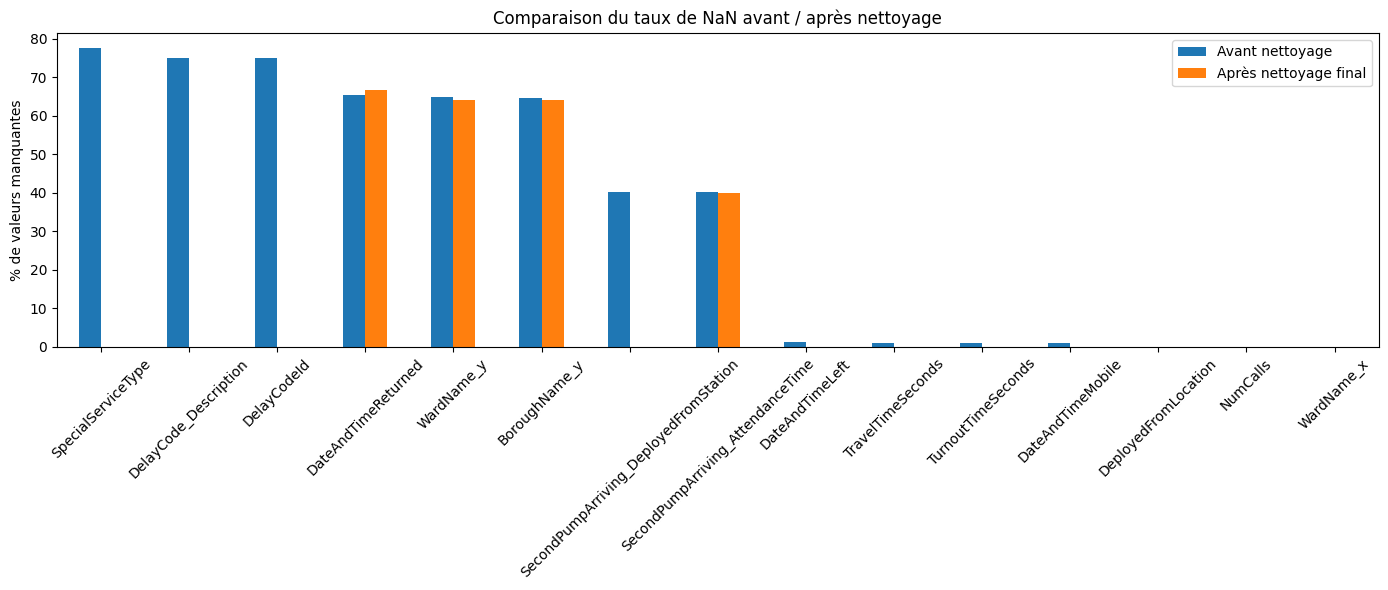

In [123]:
nan_before = (df.isna().mean() * 100).sort_values(ascending=False)
nan_after = (df_c1_1.isna().mean() * 100).sort_values(ascending=False)

nan_compare = pd.DataFrame({
    "Avant nettoyage": nan_before,
    "Après nettoyage final": nan_after
}).fillna(0)

nan_compare["Max_NaN"] = nan_compare.max(axis=1)
nan_compare = nan_compare.sort_values("Max_NaN", ascending=False).drop(columns="Max_NaN").head(15)

plt.figure(figsize=(14,6))
nan_compare.plot(kind="bar", ax=plt.gca())
plt.title("Comparaison du taux de NaN avant / après nettoyage")
plt.ylabel("% de valeurs manquantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Comparaison mean vs median vs suppression


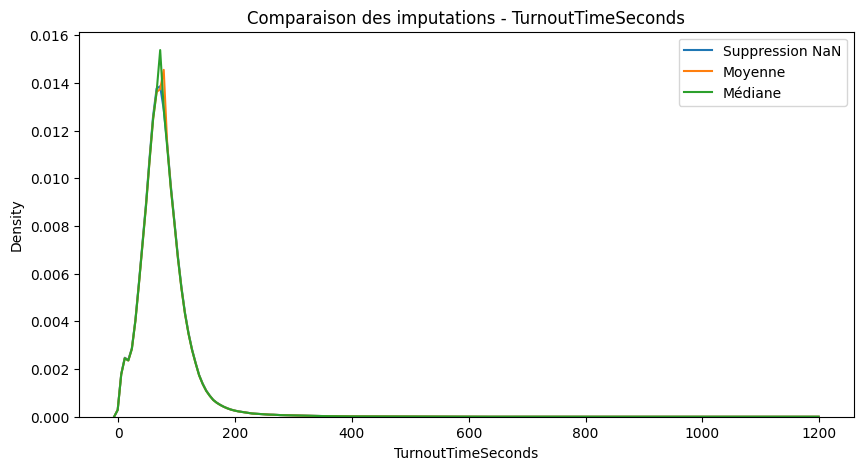

In [124]:

col = "TurnoutTimeSeconds"

s = df[col]

s_drop = s.dropna()
s_mean = s.fillna(s.mean())
s_median = s.fillna(s.median())

plt.figure(figsize=(10,5))
sns.kdeplot(s_drop, label="Suppression NaN")
sns.kdeplot(s_mean, label="Moyenne")
sns.kdeplot(s_median, label="Médiane")
plt.title(f"Comparaison des imputations - {col}")
plt.legend()
plt.show()

## Comparaison stats avant / après imputation

In [125]:

cols = ["TurnoutTimeSeconds","TravelTimeSeconds","NumCalls"]

summary = []

for col in cols:
    summary.append({
        "Variable": col,
        "NaN avant (%)": df[col].isna().mean()*100,
        "NaN après (%)": df_c[col].isna().mean()*100,
        "Mean avant": df[col].mean(),
        "Mean après": df_c[col].mean(),
        "Median avant": df[col].median(),
        "Median après": df_c[col].median()
    })

pd.DataFrame(summary)

,Variable,NaN avant (%),NaN après (%),Mean avant,Mean après,Median avant,Median après
0,TurnoutTimeSeconds,1.047820,0.0,78.598255,78.190919,73.0,73.0
1,TravelTimeSeconds,1.051747,0.0,276.415553,276.896084,250.0,251.0
2,NumCalls,0.048357,0.0,1.365101,1.365300,1.0,1.0


## Comparaison visuelle du capping


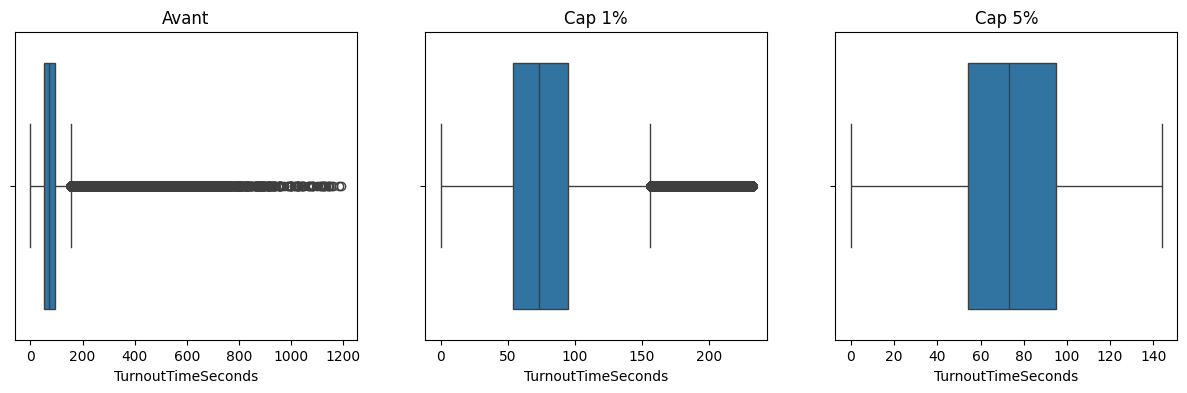

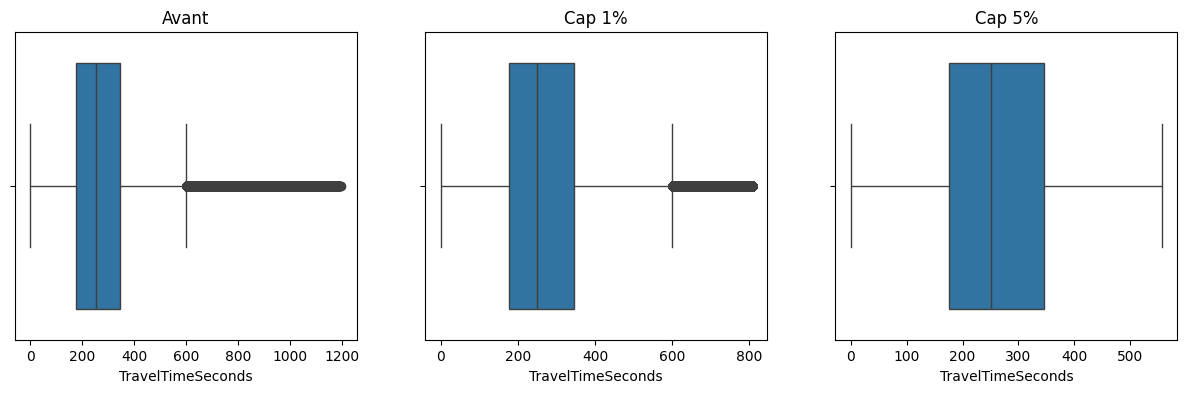

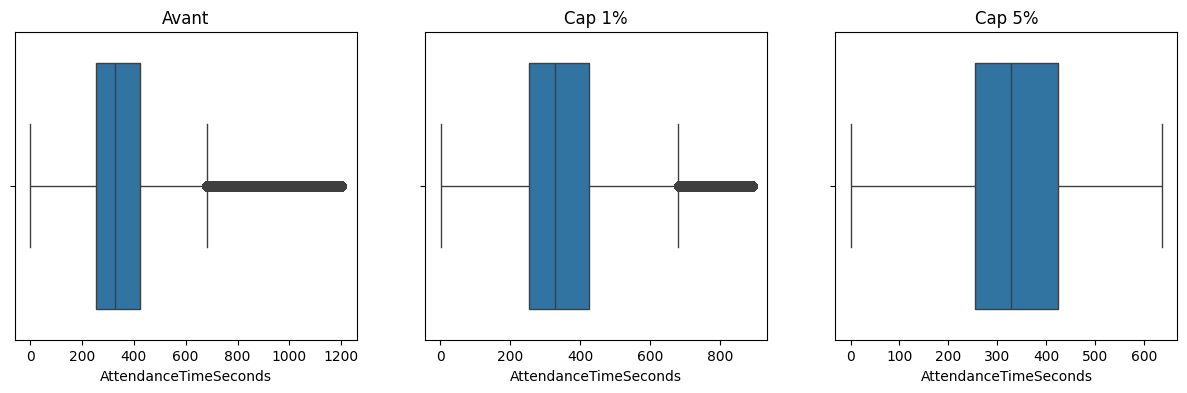

In [126]:

cols = ["TurnoutTimeSeconds","TravelTimeSeconds","AttendanceTimeSeconds"]

for col in cols:

    fig, axes = plt.subplots(1,3,figsize=(15,4))

    sns.boxplot(x=df_c1[col], ax=axes[0])
    axes[0].set_title("Avant")

    sns.boxplot(x=df_c1_1[col], ax=axes[1])
    axes[1].set_title("Cap 1%")

    sns.boxplot(x=df_c1_5[col], ax=axes[2])
    axes[2].set_title("Cap 5%")

    plt.show()

## Comparaison des distributions


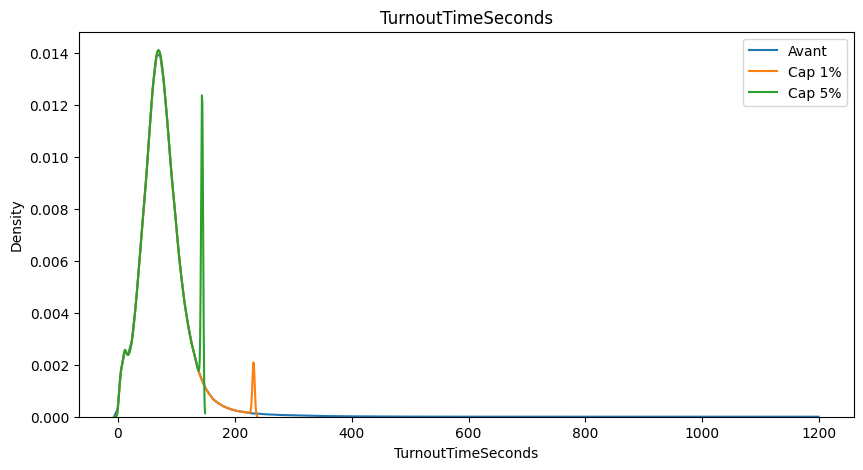

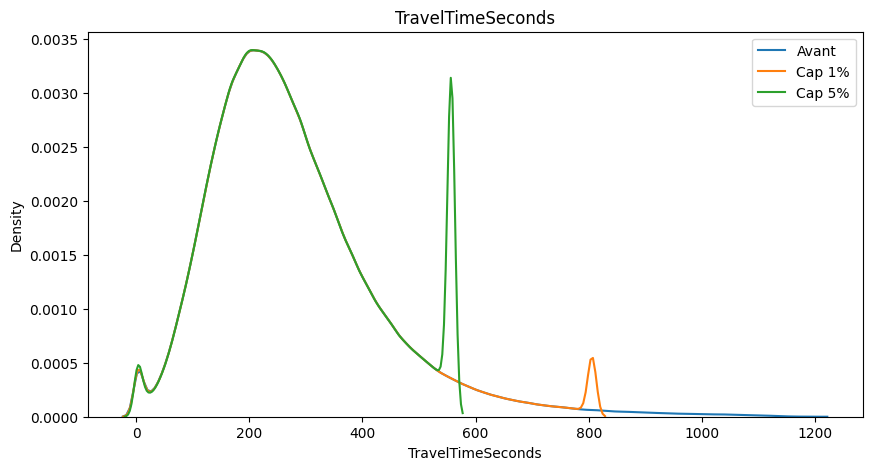

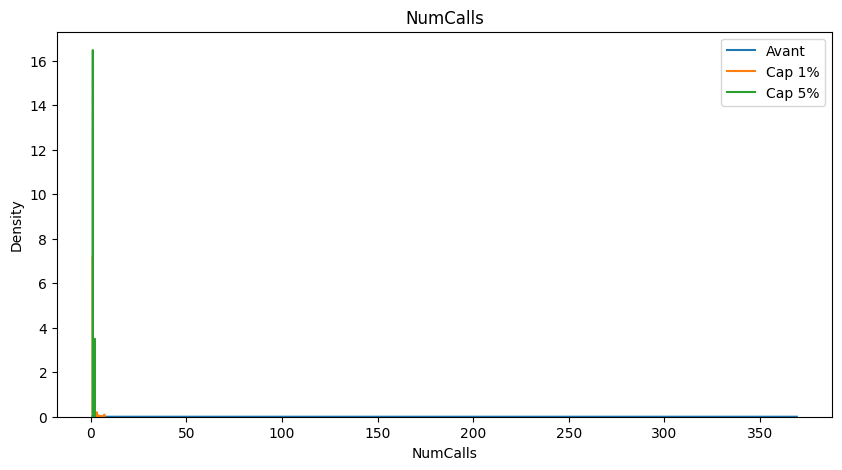

In [127]:

cols = ["TurnoutTimeSeconds","TravelTimeSeconds","NumCalls"]

for col in cols:

    plt.figure(figsize=(10,5))
    sns.kdeplot(df_c1[col], label="Avant")
    sns.kdeplot(df_c1_1[col], label="Cap 1%")
    sns.kdeplot(df_c1_5[col], label="Cap 5%")
    plt.title(col)
    plt.legend()
    plt.show()

## Stats globales

In [128]:

cols = ["TurnoutTimeSeconds","TravelTimeSeconds","NumCalls","PumpCount"]

summary = []

for col in cols:
    summary.append({
        "Variable": col,
        "Mean avant": df[col].mean(),
        "Mean après": df_c1_1[col].mean(),
        "Max avant": df[col].max(),
        "Max après": df_c1_1[col].max()
    })

pd.DataFrame(summary)

,Variable,Mean avant,Mean après,Max avant,Max après
0,TurnoutTimeSeconds,78.598255,77.299874,1192.0,232.0
1,TravelTimeSeconds,276.415553,275.672064,1198.0,806.0
2,NumCalls,1.365101,1.293229,369.0,7.0
3,PumpCount,2.074014,2.043300,402.0,6.0


## Comparaison qualitative


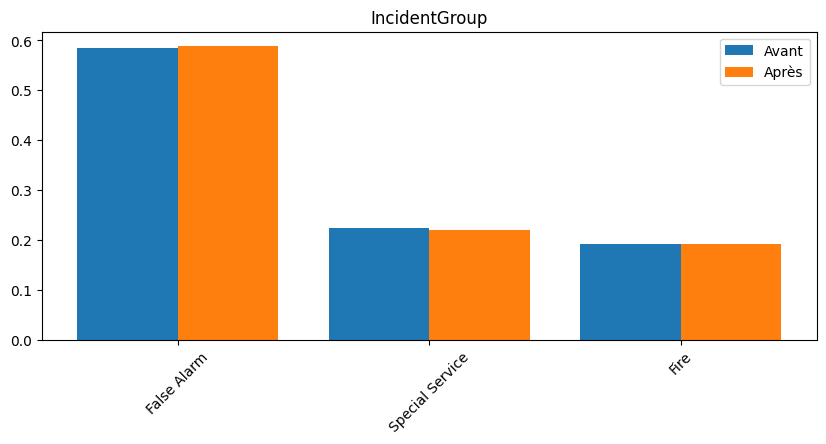

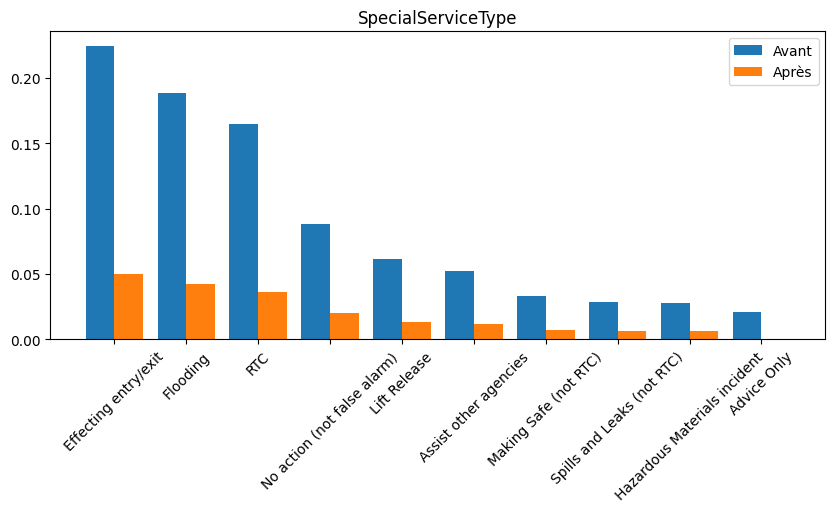

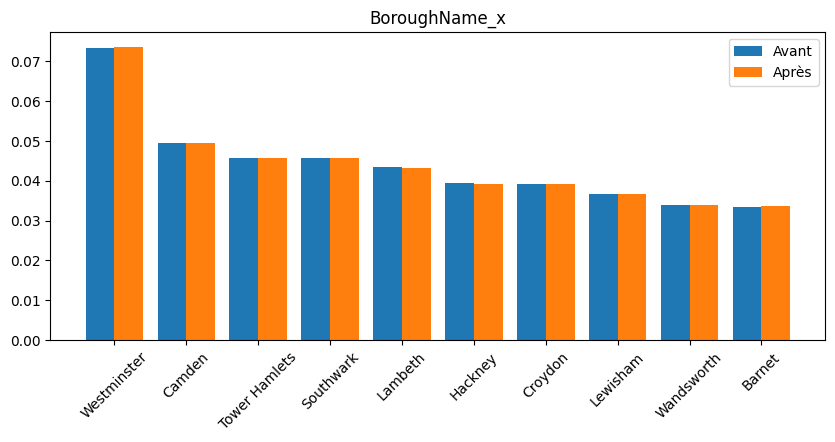

In [129]:

cols = ["IncidentGroup","SpecialServiceType","BoroughName_x"]

for col in cols:

    before = df[col].value_counts(normalize=True).head(10)
    after = df_c1_1[col].value_counts(normalize=True).head(10)

    labels = before.index
    x = np.arange(len(labels))

    plt.figure(figsize=(10,4))
    plt.bar(x-0.2, before.values, width=0.4, label="Avant")
    plt.bar(x+0.2, [after.get(l,0) for l in labels], width=0.4, label="Après")
    plt.xticks(x, labels, rotation=45)
    plt.title(col)
    plt.legend()
    plt.show()

## Evolution du nombre de lignes


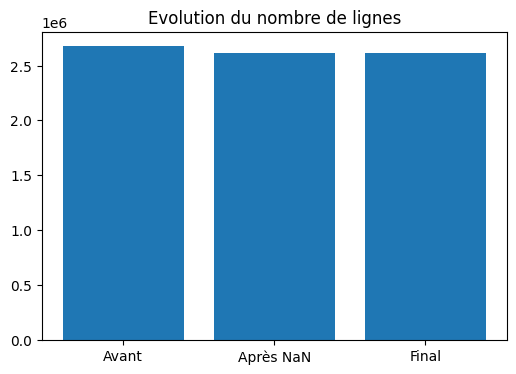

{'Avant': 2673838, 'Après NaN': 2611983, 'Final': 2611983}


In [130]:

steps = {
    "Avant": len(df),
    "Après NaN": len(df_c),
    "Final": len(df_c1_1)
}

plt.figure(figsize=(6,4))
plt.bar(steps.keys(), steps.values())
plt.title("Evolution du nombre de lignes")
plt.show()

print(steps)

# ETAPE 6

##Préparation du dataset final

In [131]:


df_final = df_c1_1.copy()

# Reset de l'index pour éviter des incohérences après export
df_final.reset_index(drop=True, inplace=True)

# Vérification rapide
print("Shape final :", df_final.shape)
df_final.head()

Shape final : (2611983, 51)


,IncidentNumber,DayOfCall,MonthOfCall,YearOfCall,TimeOfCall,HourOfCall_x,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,...,PerformanceReporting,PumpOrder,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,DelayCodeId,DelayCode_Description,PlusCode_Code,PlusCode_Description,SecondPumpMobilised
0,37948091.0,7,3,2009,07:29:27,7,Fire,Primary Fire,NotApplicable,Dwelling,...,1,1,H32,Norbury,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,True
1,37948091.0,7,3,2009,07:29:27,7,Fire,Primary Fire,NotApplicable,Dwelling,...,2,2,H32,Norbury,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,True
2,37950091.0,7,3,2009,07:30:44,7,False Alarm,AFA,NotApplicable,Non Residential,...,1,1,G56,Heathrow,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,False
3,37951091.0,7,3,2009,07:30:46,7,Special Service,Special Service,Lift Release,Dwelling,...,1,1,F22,Poplar,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,False
4,37953091.0,7,3,2009,07:36:26,7,Fire,Primary Fire,NotApplicable,Road Vehicle,...,1,1,H39,Surbiton,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,False


## Vérification des NaN restants


In [132]:

nan_final = (df_final.isna().mean() * 100).sort_values(ascending=False)

print("Top variables avec NaN restants (%) :")
display(nan_final.head(10))

# Vérification globale
print("\nNombre total de NaN :", df_final.isna().sum().sum())

Top variables avec NaN restants (%) :


,0
DateAndTimeReturned,66.550318
WardName_y,64.075149
BoroughName_y,64.036251
SecondPumpArriving_AttendanceTime,39.826255
TimeOfCall,0.000000
HourOfCall_x,0.000000
IncidentGroup,0.000000
YearOfCall,0.000000
SpecialServiceType,0.000000
PropertyCategory,0.000000



Nombre total de NaN : 6124786


##Définition du chemin d’export

In [133]:


OUTPUT_PATH = '/content/drive/My Drive/London Fire Brigade/Processed/'

file_name = 'lfb_cleaned_final.csv'
file_path = OUTPUT_PATH + file_name

print("Chemin d'export :", file_path)

Chemin d'export : /content/drive/My Drive/London Fire Brigade/Processed/lfb_cleaned_final.csv


## Export du fichier CSV

In [134]:
df_final.to_csv(file_path, index=False)

print("Export réalisé avec succès")

Export réalisé avec succès


## Vérification du fichier exporté


In [135]:

df_check = pd.read_csv(file_path)

print("Shape du fichier exporté :", df_check.shape)

df_check.head()

/tmp/ipykernel_340/2674214248.py:1: DtypeWarning: Columns (0,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_check = pd.read_csv(file_path)


Shape du fichier exporté : (2611983, 51)


,IncidentNumber,DayOfCall,MonthOfCall,YearOfCall,TimeOfCall,HourOfCall_x,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,...,PerformanceReporting,PumpOrder,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,DelayCodeId,DelayCode_Description,PlusCode_Code,PlusCode_Description,SecondPumpMobilised
0,37948091.0,7,3,2009,07:29:27,7,Fire,Primary Fire,NotApplicable,Dwelling,...,1,1,H32,Norbury,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,True
1,37948091.0,7,3,2009,07:29:27,7,Fire,Primary Fire,NotApplicable,Dwelling,...,2,2,H32,Norbury,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,True
2,37950091.0,7,3,2009,07:30:44,7,False Alarm,AFA,NotApplicable,Non Residential,...,1,1,G56,Heathrow,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,False
3,37951091.0,7,3,2009,07:30:46,7,Special Service,Special Service,Lift Release,Dwelling,...,1,1,F22,Poplar,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,False
4,37953091.0,7,3,2009,07:36:26,7,Fire,Primary Fire,NotApplicable,Road Vehicle,...,1,1,H39,Surbiton,Home Station,NoDelay,NoDelay,Initial,Initial Mobilisation,False
